In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [258]:
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [259]:
df = pd.read_csv("../dataset/Restaurant.csv")
df.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,VIOLATION CODE,VIOLATION DESCRIPTION,CRITICAL FLAG,SCORE,GRADE,GRADE DATE,RECORD DATE,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50163224,BAKED CHEESE HAUS LTD,Manhattan,1,HERALD SQUARE,10001.0,6086301355,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.750542,-73.987541,105.0,4.0,10900.0,1089436.0,1.008100e+09,MN17,POINT (-73.987541021756 40.750541907818)
1,50170678,D'S GRAB N GO,Brooklyn,74,RICHARDSON STREET,11211.0,6463025617,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.718374,-73.949138,301.0,34.0,51500.0,3068058.0,3.027320e+09,BK73,POINT (-73.94913846043 40.718373646442)
2,50171263,NAYA ROCK CENTER LLC,Manhattan,30,ROCKEFELLER PLAZA,10112.0,2124612812,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.758747,-73.978692,105.0,4.0,10400.0,1076262.0,1.012658e+09,MN17,POINT (-73.978692223615 40.758747437799)
3,50172771,AZ&G INC,Queens,133-33,39 AVENUE,11354.0,7188198818,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.759110,-73.834161,407.0,20.0,87100.0,4000000.0,4.049728e+09,QN22,POINT (-73.834160749112 40.759109919719)
4,50165402,AREFIN'S TEA MANIA NEW YORK,Queens,98-04,101 AVENUE,11416.0,3478844480,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.685049,-73.843194,409.0,32.0,4001.0,4439922.0,4.091050e+09,QN53,POINT (-73.843193921 40.685049473493)


In [260]:
df.describe()

,CAMIS,ZIPCODE,SCORE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL
count,2.967660e+05,293576.000000,280188.000000,295339.000000,295339.000000,292176.000000,292203.000000,292203.000000,2.909300e+05,2.953390e+05
mean,4.806145e+07,10706.923161,25.161749,40.292099,-73.148456,254.923769,20.568711,29882.587995,2.586012e+06,2.478446e+09
std,3.755423e+06,616.227171,18.731612,4.192801,7.611227,130.374503,15.668773,31292.127581,1.356210e+06,1.338448e+09
min,3.007544e+07,6605.000000,0.000000,0.000000,-74.249101,101.000000,1.000000,100.000000,1.000000e+06,1.000000e+00
25%,5.000430e+07,10023.000000,12.000000,40.686661,-73.988620,106.000000,4.000000,8000.000000,1.051461e+06,1.011110e+09
50%,5.009207e+07,11101.000000,21.000000,40.732855,-73.955697,302.000000,20.000000,17300.000000,3.021633e+06,3.008020e+09
75%,5.012999e+07,11232.000000,33.000000,40.761237,-73.893827,402.000000,34.000000,42600.000000,4.011502e+06,4.006290e+09
max,5.018247e+07,69361.000000,203.000000,40.912822,0.000000,595.000000,51.000000,162100.000000,5.799501e+06,5.270001e+09


In [261]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296766 entries, 0 to 296765
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  296766 non-null  int64  
 1   DBA                    296764 non-null  object 
 2   BORO                   296766 non-null  object 
 3   BUILDING               295807 non-null  object 
 4   STREET                 296765 non-null  object 
 5   ZIPCODE                293576 non-null  float64
 6   PHONE                  296752 non-null  object 
 7   CUISINE DESCRIPTION    293485 non-null  object 
 8   INSPECTION DATE        296766 non-null  object 
 9   ACTION                 293485 non-null  object 
 10  VIOLATION CODE         291191 non-null  object 
 11  VIOLATION DESCRIPTION  291190 non-null  object 
 12  CRITICAL FLAG          296766 non-null  object 
 13  SCORE                  280188 non-null  float64
 14  GRADE                  146385 non-nu

# Early Preprocessing

## Ubah ke Inspection Level ##

In [262]:
for col in ["INSPECTION DATE", "GRADE DATE", "RECORD DATE"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

record_date = df["RECORD DATE"].dropna().max()
start_date = record_date - pd.DateOffset(years=3)

df_recent = df[
    (df["INSPECTION DATE"].notna()) &
    (df["INSPECTION DATE"] >= start_date) &
    (df["INSPECTION DATE"] <= record_date)
].copy()

df_recent["SCORE"] = pd.to_numeric(df_recent["SCORE"], errors="coerce")
df_recent["BORO"] = df_recent["BORO"].replace("0", "Unknown")
df_recent["VIOLATION CODE"] = df_recent["VIOLATION CODE"].astype("string").str.strip()
df_recent["CRITICAL FLAG"] = df_recent["CRITICAL FLAG"].astype("string").str.strip().str.lower()

inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

df_ins = (
    df_recent.groupby(inspection_key, as_index=False, dropna=False)
    .agg(
        DBA=("DBA", "first"),
        BORO=("BORO", "first"),
        BUILDING=("BUILDING", "first"),
        STREET=("STREET", "first"),
        ZIPCODE=("ZIPCODE", "first"),
        PHONE=("PHONE", "first"),
        CUISINE_DESCRIPTION=("CUISINE DESCRIPTION", "first"),
        ACTION=("ACTION", "first"),
        SCORE=("SCORE", "first"),
        GRADE=("GRADE", "first"),
        GRADE_DATE=("GRADE DATE", "first"),
        Latitude=("Latitude", "first"),
        Longitude=("Longitude", "first"),
        Community_Board=("Community Board", "first"),
        Council_District=("Council District", "first"),
        Census_Tract=("Census Tract", "first"),
        BIN=("BIN", "first"),
        BBL=("BBL", "first"),
        NTA=("NTA", "first"),
        violation_count=("VIOLATION CODE", lambda x: x.dropna().ne("").sum()),
        critical_count=("CRITICAL FLAG", lambda x: (x == "critical").sum()),
        has_critical=("CRITICAL FLAG", lambda x: (x == "critical").any())
    )
)

df_ins.head()

,CAMIS,INSPECTION DATE,INSPECTION TYPE,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE_DESCRIPTION,ACTION,SCORE,GRADE,GRADE_DATE,Latitude,Longitude,Community_Board,Council_District,Census_Tract,BIN,BBL,NTA,violation_count,critical_count,has_critical
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,38.0,None,NaT,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,2,True
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,12.0,A,2023-08-22,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,10.0,A,2024-11-08,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,7.0,A,2026-02-27,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,2,1,True
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,D.J. REYNOLDS,Manhattan,351,WEST 57 STREET,10019.0,2122452912,Irish,Violations were cited in the following area(s).,10.0,A,2023-04-23,40.767326,-73.984310,104.0,3.0,13900.0,1026048.0,1.010480e+09,MN15,2,2,True


In [263]:
df_ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77629 entries, 0 to 77628
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CAMIS                77629 non-null  int64         
 1   INSPECTION DATE      77629 non-null  datetime64[ns]
 2   INSPECTION TYPE      77629 non-null  object        
 3   DBA                  77629 non-null  object        
 4   BORO                 77629 non-null  object        
 5   BUILDING             77390 non-null  object        
 6   STREET               77629 non-null  object        
 7   ZIPCODE              76772 non-null  float64       
 8   PHONE                77626 non-null  object        
 9   CUISINE_DESCRIPTION  77629 non-null  object        
 10  ACTION               77629 non-null  object        
 11  SCORE                68860 non-null  float64       
 12  GRADE                46347 non-null  object        
 13  GRADE_DATE           44221 non-

In [264]:
df_ins.duplicated().sum()

np.int64(0)

In [265]:
df_ins.isna().sum()

CAMIS                      0
INSPECTION DATE            0
INSPECTION TYPE            0
DBA                        0
BORO                       0
BUILDING                 239
STREET                     0
ZIPCODE                  857
PHONE                      3
CUISINE_DESCRIPTION        0
ACTION                     0
SCORE                   8769
GRADE                  31282
GRADE_DATE             33408
Latitude                 386
Longitude                386
Community_Board         1234
Council_District        1230
Census_Tract            1230
BIN                     1604
BBL                      386
NTA                     1234
violation_count            0
critical_count             0
has_critical               0
dtype: int64

**Drop Missing Value in Score**

In [266]:
df_ins = df_ins.dropna(subset=["SCORE"]).copy()
df_ins['SCORE'].isna().sum()

np.int64(0)

**Penjelasan:** Drop baris yang SCORE-nya null karena SCORE adalah kolom target, tidak bisa diimputasi

In [267]:
df_ins.columns

Index(['CAMIS', 'INSPECTION DATE', 'INSPECTION TYPE', 'DBA', 'BORO',
       'BUILDING', 'STREET', 'ZIPCODE', 'PHONE', 'CUISINE_DESCRIPTION',
       'ACTION', 'SCORE', 'GRADE', 'GRADE_DATE', 'Latitude', 'Longitude',
       'Community_Board', 'Council_District', 'Census_Tract', 'BIN', 'BBL',
       'NTA', 'violation_count', 'critical_count', 'has_critical'],
      dtype='object')

## Ubah Tipe Data ##

In [268]:
for col in ["INSPECTION DATE", "GRADE_DATE"]:
    df_ins[col] = pd.to_datetime(df_ins[col], errors="coerce")

for col in ["SCORE", "Latitude", "Longitude"]:
    df_ins[col] = pd.to_numeric(df_ins[col], errors="coerce")

df_ins["ZIPCODE"] = df_ins["ZIPCODE"].astype("string").astype("category")

for col in ["BORO", "CUISINE_DESCRIPTION", "INSPECTION TYPE"]:
    df_ins[col] = df_ins[col].astype("category")
    
df_ins.dtypes

CAMIS                           int64
INSPECTION DATE        datetime64[ns]
INSPECTION TYPE              category
DBA                            object
BORO                         category
BUILDING                       object
STREET                         object
ZIPCODE                      category
PHONE                          object
CUISINE_DESCRIPTION          category
ACTION                         object
SCORE                         float64
GRADE                          object
GRADE_DATE             datetime64[ns]
Latitude                      float64
Longitude                     float64
Community_Board               float64
Council_District              float64
Census_Tract                  float64
BIN                           float64
BBL                           float64
NTA                            object
violation_count                 int64
critical_count                  int64
has_critical                     bool
dtype: object

**Penjelasan:** Yang Date itu krn tanggal jd pake datetime, yg score, latitude dan longitude itu bakal diproses secara numerik, selainnya itu krn emang kategorikal jadi diubah ke category aja

## Fitur inti ##

In [269]:
df_ins["inspection_year"] = df_ins["INSPECTION DATE"].dt.year
df_ins["inspection_month"] = df_ins["INSPECTION DATE"].dt.month
df_ins["inspection_quarter"] = df_ins["INSPECTION DATE"].dt.quarter
df_ins["inspection_dayofweek"] = df_ins["INSPECTION DATE"].dt.dayofweek

base_features = [
    "CUISINE_DESCRIPTION",
    "BORO",
    "ZIPCODE",
    "Latitude",
    "Longitude",
    "Community_Board",
    "INSPECTION TYPE",
    "inspection_year",
    "inspection_month",
    "inspection_quarter",
    "inspection_dayofweek"
]

df_base = df_ins[
    ["CAMIS", "INSPECTION DATE", "SCORE"] + base_features
].copy()

df_base.head()

,CAMIS,INSPECTION DATE,SCORE,CUISINE_DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,Community_Board,INSPECTION TYPE,inspection_year,inspection_month,inspection_quarter,inspection_dayofweek
0,30075445,2023-08-01,38.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2023,8,3,1
1,30075445,2023-08-22,12.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Re-inspection,2023,8,3,1
2,30075445,2024-11-08,10.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2024,11,4,4
3,30075445,2026-02-27,7.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2026,2,1,4
4,30191841,2023-04-23,10.0,Irish,Manhattan,10019.0,40.767326,-73.984310,104.0,Cycle Inspection / Initial Inspection,2023,4,2,6


In [270]:
df_base.columns

Index(['CAMIS', 'INSPECTION DATE', 'SCORE', 'CUISINE_DESCRIPTION', 'BORO',
       'ZIPCODE', 'Latitude', 'Longitude', 'Community_Board',
       'INSPECTION TYPE', 'inspection_year', 'inspection_month',
       'inspection_quarter', 'inspection_dayofweek'],
      dtype='object')

In [271]:
df_base.dtypes

CAMIS                            int64
INSPECTION DATE         datetime64[ns]
SCORE                          float64
CUISINE_DESCRIPTION           category
BORO                          category
ZIPCODE                       category
Latitude                       float64
Longitude                      float64
Community_Board                float64
INSPECTION TYPE               category
inspection_year                  int32
inspection_month                 int32
inspection_quarter               int32
inspection_dayofweek             int32
dtype: object

## Handle Missing Value Boro, Zipcode, Cuisine Description, Inspection Type ##

In [272]:
cat_cols = ["BORO", "ZIPCODE", "CUISINE_DESCRIPTION", "INSPECTION TYPE"]

for col in cat_cols:
    df_base[col] = df_base[col].replace(r"^\s*$", pd.NA, regex=True)

    if str(df_base[col].dtype) == "category":
        if "Unknown" not in df_base[col].cat.categories:
            df_base[col] = df_base[col].cat.add_categories(["Unknown"])

    df_base[col] = df_base[col].fillna("Unknown")
    
df_base[cat_cols].isna().sum()

BORO                   0
ZIPCODE                0
CUISINE_DESCRIPTION    0
INSPECTION TYPE        0
dtype: int64

In [273]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68860 entries, 0 to 77627
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CAMIS                 68860 non-null  int64         
 1   INSPECTION DATE       68860 non-null  datetime64[ns]
 2   SCORE                 68860 non-null  float64       
 3   CUISINE_DESCRIPTION   68860 non-null  category      
 4   BORO                  68860 non-null  category      
 5   ZIPCODE               68860 non-null  category      
 6   Latitude              68505 non-null  float64       
 7   Longitude             68505 non-null  float64       
 8   Community_Board       67732 non-null  float64       
 9   INSPECTION TYPE       68860 non-null  category      
 10  inspection_year       68860 non-null  int32         
 11  inspection_month      68860 non-null  int32         
 12  inspection_quarter    68860 non-null  int32         
 13  inspection_dayofweek 

## Handle Missing Value Community Board ##

In [274]:
df_base["Community_Board"] = df_base["Community_Board"].astype(str)
df_base["Community_Board"] = df_base["Community_Board"].replace(r"^\s*$", pd.NA, regex=True)
df_base["Community_Board"] = df_base["Community_Board"].fillna("Unknown")
df_base[["Community_Board"]].isna().sum()

Community_Board    0
dtype: int64

## Handle Missing Value Latitude Longitude ##

In [275]:
df_base[['Latitude', 'Longitude']].isna().sum()

Latitude     355
Longitude    355
dtype: int64

In [276]:
df_base["Latitude"] = pd.to_numeric(df_base["Latitude"], errors="coerce")
df_base["Longitude"] = pd.to_numeric(df_base["Longitude"], errors="coerce")

df_base.loc[df_base["Latitude"] == 0, "Latitude"] = pd.NA
df_base.loc[df_base["Longitude"] == 0, "Longitude"] = pd.NA

df_base["Latitude"] = df_base["Latitude"].fillna(
    df_base.groupby("CAMIS")["Latitude"].transform("median")
)

df_base["Longitude"] = df_base["Longitude"].fillna(
    df_base.groupby("CAMIS")["Longitude"].transform("median")
)

df_base["Latitude"] = df_base["Latitude"].fillna(df_base["Latitude"].median())
df_base["Longitude"] = df_base["Longitude"].fillna(df_base["Longitude"].median())

In [277]:
df_base[['Latitude', 'Longitude']].isna().sum()

Latitude     0
Longitude    0
dtype: int64

In [278]:
df_base.isna().sum()

CAMIS                   0
INSPECTION DATE         0
SCORE                   0
CUISINE_DESCRIPTION     0
BORO                    0
ZIPCODE                 0
Latitude                0
Longitude               0
Community_Board         0
INSPECTION TYPE         0
inspection_year         0
inspection_month        0
inspection_quarter      0
inspection_dayofweek    0
dtype: int64

## Top Category Cuisine & Inspection Type ##

In [279]:
TOP_N_CUISINE = 15
TOP_N_INSTYPE = 5

top_cuisine = df_base["CUISINE_DESCRIPTION"].value_counts().nlargest(TOP_N_CUISINE).index
df_base["CUISINE_DESCRIPTION"] = (
    df_base["CUISINE_DESCRIPTION"]
    .apply(lambda x: x if x in top_cuisine else "Other")
)

top_instype = df_base["INSPECTION TYPE"].value_counts().nlargest(TOP_N_INSTYPE).index
df_base["INSPECTION TYPE"] = (
    df_base["INSPECTION TYPE"]
    .apply(lambda x: x if x in top_instype else "Other")
)

In [280]:
print(df_base["CUISINE_DESCRIPTION"].value_counts())
print()
print(df_base["INSPECTION TYPE"].value_counts())
print(df_base["CUISINE_DESCRIPTION"].nunique())
print(df_base["INSPECTION TYPE"].nunique())

CUISINE_DESCRIPTION
Other                             18539
American                          11072
Chinese                            6221
Coffee/Tea                         5862
Pizza                              4184
Latin American                     2900
Bakery Products/Desserts           2778
Mexican                            2708
Japanese                           2364
Caribbean                          2259
Italian                            2191
Chicken                            1914
Donuts                             1701
Juice, Smoothies, Fruit Salads     1418
Spanish                            1414
Hamburgers                         1335
Name: count, dtype: int64

INSPECTION TYPE
Cycle Inspection / Initial Inspection            38133
Cycle Inspection / Re-inspection                 14453
Pre-permit (Operational) / Initial Inspection     9378
Other                                             3067
Pre-permit (Operational) / Re-inspection          2774
Cycle Inspection / Reo

**Penjelasan:** Cuisine diambil yang top 15 agar tidak terlalu banyak kategori karena diluar top 15 jumlahnya juga dikit, inspection type diambil yang top 5 aja dengan alasan yang sama selebihnya dikelompokkan sebagai Other

# Advanced Preprocessing

## Step 1 - Advanced Preprocessing: Feature Engineering dari Violation ##

- `df_ins` sudah mengagregasi `violation_count`, `critical_count`, dan `has_critical`
- Namun fitur-fitur ini **tidak ikut masuk ke `df_base`** saat pemilihan kolom
- Langkah ini melengkapi fitur violation yang kurang, lalu menarik semuanya ke `df_base`


In [281]:
inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

viol_clean = df_recent.copy()
viol_clean["VIOLATION CODE"]  = viol_clean["VIOLATION CODE"].astype(str).str.strip()
viol_clean["CRITICAL FLAG"]   = viol_clean["CRITICAL FLAG"].astype(str).str.strip().str.lower()

viol_clean = viol_clean[
    viol_clean["VIOLATION CODE"].notna() &
    (viol_clean["VIOLATION CODE"] != "") &
    (viol_clean["VIOLATION CODE"].str.lower() != "nan")
].copy()

viol_dedup = viol_clean.drop_duplicates(
    subset=inspection_key + ["VIOLATION CODE"]
).copy()

viol_features = (
    viol_dedup.groupby(inspection_key, as_index=False)
    .agg(
        violation_count    = ("VIOLATION CODE", "count"),
        unique_viol_codes  = ("VIOLATION CODE", "nunique"),
        critical_count     = ("CRITICAL FLAG", lambda x: (x == "critical").sum()),
        noncritical_count  = ("CRITICAL FLAG", lambda x: (x != "critical").sum()),
        has_critical       = ("CRITICAL FLAG", lambda x: (x == "critical").any()),
    )
)

viol_features["critical_ratio"] = (
    viol_features["critical_count"] / viol_features["violation_count"].replace(0, pd.NA)
).fillna(0)

print("Shape viol_features:", viol_features.shape)
viol_features.head()

Shape viol_features: (77629, 9)


,CAMIS,INSPECTION DATE,INSPECTION TYPE,violation_count,unique_viol_codes,critical_count,noncritical_count,has_critical,critical_ratio
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,3,3,2,1,True,0.666667
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,3,3,1,2,True,0.333333
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,3,3,1,2,True,0.333333
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,2,2,1,1,True,0.500000
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,2,2,2,0,True,1.000000


**1b. Binary Flag untuk Top Violation Codes dengan score tertinggi**

Dari EDA diketahui 9/10 violation code dengan median score tertinggi adalah critical code (05F, 06C, dst).
Membuat flag kehadiran kode-kode tersebut sebagai fitur eksplisit.


In [282]:
TOP_VIOL_CODES = ["10F", "08A", "06D", "10B", "02G", "06C", "02B", "04L", "04N", "04A", "05F", "04H", "05D", "06F"]

code_pivot = (
    viol_dedup[viol_dedup["VIOLATION CODE"].isin(TOP_VIOL_CODES)]
    .assign(val=1)
    .pivot_table(
        index=inspection_key,
        columns="VIOLATION CODE",
        values="val",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

code_pivot.columns.name = None
code_pivot = code_pivot.rename(
    columns={c: f"viol_{c}" for c in TOP_VIOL_CODES if c in code_pivot.columns}
)

print("Shape code_pivot:", code_pivot.shape)
code_pivot.head()

Shape code_pivot: (65337, 17)


,CAMIS,INSPECTION DATE,INSPECTION TYPE,viol_02B,viol_02G,viol_04A,viol_04H,viol_04L,viol_04N,viol_05D,viol_05F,viol_06C,viol_06D,viol_06F,viol_08A,viol_10B,viol_10F
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,0,0,0,0,1,0,0,0,0,0,0,1,0,0
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,0,0,0,0,0,0,0,0,1,0,0,0,0,1
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [283]:
for col in inspection_key:
    viol_features[col]  = viol_features[col].astype(str)
    code_pivot[col]     = code_pivot[col].astype(str)
    df_base[col]        = df_base[col].astype(str)

df_base = df_base.merge(viol_features, on=inspection_key, how="left")

df_base = df_base.merge(code_pivot, on=inspection_key, how="left")

viol_numeric_cols = (
    ["violation_count", "unique_viol_codes", "critical_count",
     "noncritical_count", "critical_ratio"]
    + [c for c in df_base.columns if c.startswith("viol_")]
)

df_base[viol_numeric_cols] = df_base[viol_numeric_cols].fillna(0)
df_base["has_critical"] = df_base["has_critical"].fillna(False)

print("Shape df_base setelah merge violation features:", df_base.shape)
print("\nKolom baru yang ditambahkan:")
print([c for c in df_base.columns if c in viol_numeric_cols or c == "has_critical"])

Shape df_base setelah merge violation features: (68860, 34)

Kolom baru yang ditambahkan:
['violation_count', 'unique_viol_codes', 'critical_count', 'noncritical_count', 'has_critical', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04H', 'viol_04L', 'viol_04N', 'viol_05D', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06F', 'viol_08A', 'viol_10B', 'viol_10F']


In [284]:
print("=== Info df_base ===")
print(df_base[viol_numeric_cols + ["has_critical"]].describe())
print()
print("=== Missing values fitur violation ===")
print(df_base[viol_numeric_cols + ["has_critical"]].isna().sum())
print()
print("=== Contoh data ===")
df_base[[
    "CAMIS", "INSPECTION DATE", "SCORE",
    "violation_count", "critical_count", "noncritical_count",
    "unique_viol_codes", "critical_ratio", "has_critical"
]].head(10)

=== Info df_base ===
       violation_count  unique_viol_codes  critical_count  noncritical_count  \
count     68860.000000       68860.000000    68860.000000       68860.000000   
mean          3.246660           3.246660        1.815800           1.430860   
std           2.112278           2.112278        1.526577           1.067399   
min           0.000000           0.000000        0.000000           0.000000   
25%           2.000000           2.000000        1.000000           1.000000   
50%           3.000000           3.000000        1.000000           1.000000   
75%           4.000000           4.000000        3.000000           2.000000   
max          19.000000          19.000000       13.000000           8.000000   

       critical_ratio      viol_02B      viol_02G      viol_04A      viol_04H  \
count    68860.000000  68860.000000  68860.000000  68860.000000  68860.000000   
mean         0.510207      0.187090      0.220447      0.095760      0.071580   
std          0.

,CAMIS,INSPECTION DATE,SCORE,violation_count,critical_count,noncritical_count,unique_viol_codes,critical_ratio,has_critical
0,30075445,2023-08-01,38.0,3.0,2.0,1.0,3.0,0.666667,True
1,30075445,2023-08-22,12.0,3.0,1.0,2.0,3.0,0.333333,True
2,30075445,2024-11-08,10.0,3.0,1.0,2.0,3.0,0.333333,True
3,30075445,2026-02-27,7.0,2.0,1.0,1.0,2.0,0.500000,True
4,30191841,2023-04-23,10.0,2.0,2.0,0.0,2.0,1.000000,True
5,30191841,2024-11-20,24.0,6.0,2.0,4.0,6.0,0.333333,True
6,30191841,2025-02-20,10.0,2.0,2.0,0.0,2.0,1.000000,True
7,40356018,2024-04-16,0.0,1.0,0.0,1.0,1.0,0.000000,False
8,40356018,2025-09-17,10.0,2.0,1.0,1.0,2.0,0.500000,True
9,40356483,2023-11-16,35.0,6.0,3.0,3.0,6.0,0.500000,True


## Step 2 - Advanced Preprocessing: Feature Engineering Historis per Restoran ##

**Konteks & Anti Data Leakage:**

Karena 68%+ restoran adalah **repeat offender**, riwayat inspeksi sebelumnya sangat prediktif terhadap score saat ini.

Aturan krusial: **fitur historis hanya boleh menggunakan data dari inspeksi SEBELUM tanggal inspeksi yang sedang diprediksi.**
Jika memakai data dari tanggal yang sama atau sesudahnya → **data leakage** → model terlihat bagus saat training tapi gagal di production.

**Fitur yang akan dibuat:**
| Fitur | Penjelasan |
|---|---|
| `prev_score` | Score inspeksi terakhir restoran sebelum inspeksi ini |
| `avg_score_last3` | Rata-rata score 3 inspeksi terakhir |
| `n_prev_inspections` | Jumlah inspeksi sebelumnya |
| `days_since_last_inspection` | Jarak hari dari inspeksi terakhir |
| `prev_critical_count` | Jumlah critical violation di inspeksi terakhir |
| `ever_had_critical` | Apakah restoran pernah dapat critical violation sebelumnya |


In [285]:
df_hist = df_base.copy()
df_hist["INSPECTION DATE"] = pd.to_datetime(df_hist["INSPECTION DATE"])
df_hist = df_hist.sort_values(["CAMIS", "INSPECTION DATE"]).reset_index(drop=True)

df_hist["prev_score"] = (
    df_hist.groupby("CAMIS")["SCORE"]
    .shift(1) 
)

df_hist["avg_score_last3"] = (
    df_hist.groupby("CAMIS")["SCORE"]
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

df_hist["n_prev_inspections"] = (
    df_hist.groupby("CAMIS").cumcount()
)

df_hist["prev_inspection_date"] = (
    df_hist.groupby("CAMIS")["INSPECTION DATE"].shift(1)
)
df_hist["days_since_last_inspection"] = (
    (df_hist["INSPECTION DATE"] - df_hist["prev_inspection_date"]).dt.days
)
df_hist = df_hist.drop(columns=["prev_inspection_date"])

df_hist["prev_critical_count"] = (
    df_hist.groupby("CAMIS")["critical_count"].shift(1)
)

df_hist["ever_had_critical"] = (
    df_hist.groupby("CAMIS")["has_critical"]
    .transform(lambda x: x.shift(1).fillna(False).cumsum()) > 0
)

print("Shape df_hist:", df_hist.shape)
print()
print("Missing values fitur historis:")
hist_cols = ["prev_score", "avg_score_last3", "n_prev_inspections",
             "days_since_last_inspection", "prev_critical_count", "ever_had_critical"]
print(df_hist[hist_cols].isna().sum())

Shape df_hist: (68860, 40)

Missing values fitur historis:
prev_score                    27071
avg_score_last3               27071
n_prev_inspections                0
days_since_last_inspection    27071
prev_critical_count           27071
ever_had_critical                 0
dtype: int64


**Handle Missing Value Fitur Historis**

Inspeksi pertama setiap restoran (`n_prev_inspections == 0`) akan selalu NaN pada `prev_score`, `avg_score_last3`, dll.
karena belum ada riwayat — ini **bukan error**, melainkan kondisi wajar.

Strategi imputasi:
- `prev_score` & `avg_score_last3` → isi dengan **median global** sebagai baseline
- `days_since_last_inspection` → isi dengan nilai **besar (999)** sebagai sinyal "pertama kali"
- `prev_critical_count` → isi **0** (belum pernah ada critical)
- `ever_had_critical` → isi **False**


In [286]:
df_hist["prev_score"]      = np.log1p(df_hist["prev_score"])
df_hist["avg_score_last3"] = np.log1p(df_hist["avg_score_last3"])

global_median_score = df_hist["SCORE"].median()

df_hist["prev_score"]                = df_hist["prev_score"].fillna(global_median_score)
df_hist["avg_score_last3"]           = df_hist["avg_score_last3"].fillna(global_median_score)
df_hist["days_since_last_inspection"]= df_hist["days_since_last_inspection"].fillna(999)
df_hist["prev_critical_count"]       = df_hist["prev_critical_count"].fillna(0)
df_hist["ever_had_critical"]         = df_hist["ever_had_critical"].fillna(False)

print("Missing values setelah imputasi:")
print(df_hist[hist_cols].isna().sum())
print()

df_base = df_hist.copy()

print("=== Distribusi fitur historis ===")
df_base[hist_cols].describe()

Missing values setelah imputasi:
prev_score                    0
avg_score_last3               0
n_prev_inspections            0
days_since_last_inspection    0
prev_critical_count           0
ever_had_critical             0
dtype: int64

=== Distribusi fitur historis ===


,prev_score,avg_score_last3,n_prev_inspections,days_since_last_inspection,prev_critical_count
count,68860.000000,68860.000000,68860.000000,68860.000000,68860.000000
mean,6.813723,6.875302,1.095353,573.208205,1.268995
std,5.020827,4.958028,1.239170,378.471862,1.648423
min,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2.639057,2.793208,0.000000,210.000000,0.000000
50%,3.555348,3.511545,1.000000,512.000000,1.000000
75%,13.000000,13.000000,2.000000,999.000000,2.000000
max,13.000000,13.000000,13.000000,1078.000000,13.000000


## Step 3 - Advanced Preprocessing: Feature Engineering Geospasial (Target Encoding) ##

**Konteks:**

Dari EDA diketahui lokasi (BORO, ZIPCODE, Community Board) berpengaruh terhadap SCORE.
Daripada hanya pakai label encoding biasa, kami membuat **Target Encoding berbasis agregasi** —
mengganti nilai kategorikal dengan statistik SCORE historis di wilayah tersebut.

**Strategi Anti Data Leakage:**
Target encoding harus dihitung dari **data training saja** dan di-apply ke test set.
Di tahap ini (sebelum split), kami gunakan pendekatan **Leave-One-Out** atau cukup
hitung dari keseluruhan data sebagai proxy — split resmi akan dilakukan di Step 8.

**Fitur yang akan dibuat:**
| Fitur | Penjelasan |
|---|---|
| `boro_median_score` | Median score historis per BORO |
| `boro_mean_score` | Mean score historis per BORO |
| `zipcode_median_score` | Median score historis per ZIPCODE |
| `zipcode_mean_score` | Mean score historis per ZIPCODE |
| `community_board_median_score` | Median score historis per Community Board |


In [287]:
boro_stats = (
    df_base.groupby("BORO")["SCORE"]
    .agg(boro_median_score="median", boro_mean_score="mean")
    .reset_index()
)

zipcode_stats = (
    df_base.groupby("ZIPCODE")["SCORE"]
    .agg(zipcode_median_score="median", zipcode_mean_score="mean")
    .reset_index()
)

cb_stats = (
    df_base.groupby("Community_Board")["SCORE"]
    .agg(community_board_median_score="median")
    .reset_index()
)

df_base = df_base.merge(boro_stats,    on="BORO",            how="left")
df_base = df_base.merge(zipcode_stats, on="ZIPCODE",         how="left")
df_base = df_base.merge(cb_stats,      on="Community_Board", how="left")

global_median = df_base["SCORE"].median()
geo_encode_cols = [
    "boro_median_score", "boro_mean_score",
    "zipcode_median_score", "zipcode_mean_score",
    "community_board_median_score"
]
df_base[geo_encode_cols] = df_base[geo_encode_cols].fillna(global_median)

print("Shape df_base setelah geospatial encoding:", df_base.shape)
print()
print("Missing values fitur geospatial:")
print(df_base[geo_encode_cols].isna().sum())

Shape df_base setelah geospatial encoding: (68860, 45)

Missing values fitur geospatial:
boro_median_score               0
boro_mean_score                 0
zipcode_median_score            0
zipcode_mean_score              0
community_board_median_score    0
dtype: int64


In [288]:
geo_hist_cols = geo_encode_cols + hist_cols

print("=== Distribusi fitur geospatial ===")
print(df_base[geo_encode_cols].describe())
print()
print("=== Contoh Perbandingan: BORO vs boro_median_score ===")
print(df_base.groupby("BORO")[["boro_median_score", "boro_mean_score"]].first().sort_values("boro_median_score", ascending=False))
print()
print("=== Total kolom df_base saat ini ===")
print(f"Shape: {df_base.shape}")
print(df_base.columns.tolist())


=== Distribusi fitur geospatial ===
       boro_median_score  boro_mean_score  zipcode_median_score  \
count       68860.000000     68860.000000          68860.000000   
mean           12.625385        18.118501             12.754676   
std             0.484027         0.858589              1.547715   
min            12.000000        15.463415              2.000000   
25%            12.000000        17.384430             12.000000   
50%            13.000000        17.723636             13.000000   
75%            13.000000        18.158726             13.000000   
max            13.000000        19.551193             28.000000   

       zipcode_mean_score  community_board_median_score  
count        68860.000000                  68860.000000  
mean            18.118501                     12.773003  
std              2.068082                      1.044980  
min              4.000000                      4.000000  
25%             16.851372                     12.000000  
50%         

## Step 4 - Correlation Analysis: Seleksi Fitur terhadap Target (SCORE) ##

**Tujuan:** Identifikasi fitur mana yang benar-benar berkorelasi dengan SCORE sebelum masuk modeling.

Dua pendekatan digunakan secara bersamaan:
- **Pearson / Spearman** → untuk fitur numerik (linear vs monotonic)
- **Eta-squared (η²)** → untuk fitur kategorikal (kekuatan asosiasi via ANOVA)

Threshold keputusan (bisa disesuaikan):
- Numerik: |Spearman ρ| ≥ 0.05 → **keep**
- Kategorikal: η² ≥ 0.01 → **keep** (efek kecil tapi informatif)


In [289]:
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

exclude_cols = {"CAMIS", "INSPECTION DATE", "SCORE"}
num_cols = [
    c for c in df_base.select_dtypes(include="number").columns
    if c not in exclude_cols
]

corr_results = []
for col in num_cols:
    valid = df_base[[col, "SCORE"]].dropna()
    if len(valid) < 30:
        continue
    pearson_r,  pearson_p  = stats.pearsonr(valid[col],  valid["SCORE"])
    spearman_r, spearman_p = stats.spearmanr(valid[col], valid["SCORE"])
    corr_results.append({
        "feature":     col,
        "pearson_r":   round(pearson_r,  4),
        "pearson_p":   round(pearson_p,  4),
        "spearman_r":  round(spearman_r, 4),
        "spearman_p":  round(spearman_p, 4),
        "abs_spearman": abs(spearman_r),
    })

df_corr = (
    pd.DataFrame(corr_results)
    .sort_values("abs_spearman", ascending=False)
    .reset_index(drop=True)
)

SPEARMAN_THRESHOLD = 0.05
df_corr["keep"] = df_corr["abs_spearman"] >= SPEARMAN_THRESHOLD

print(f"Total fitur numerik diperiksa: {len(df_corr)}")
print(f"Fitur yang cukup berkorelasi (|ρ| ≥ {SPEARMAN_THRESHOLD}): {df_corr['keep'].sum()}")
print(f"Fitur yang lemah / tidak berkorelasi: {(~df_corr['keep']).sum()}")
print()
df_corr


Total fitur numerik diperiksa: 35
Fitur yang cukup berkorelasi (|ρ| ≥ 0.05): 26
Fitur yang lemah / tidak berkorelasi: 9



,feature,pearson_r,pearson_p,spearman_r,spearman_p,abs_spearman,keep
0,critical_count,0.8106,0.0000,0.8381,0.0000,0.838134,True
1,violation_count,0.7831,0.0000,0.8176,0.0000,0.817552,True
2,unique_viol_codes,0.7831,0.0000,0.8176,0.0000,0.817552,True
3,viol_08A,0.4211,0.0000,0.4795,0.0000,0.479486,True
4,critical_ratio,0.2954,0.0000,0.4245,0.0000,0.424459,True
5,viol_02G,0.3507,0.0000,0.3808,0.0000,0.380793,True
6,noncritical_count,0.3904,0.0000,0.3651,0.0000,0.365133,True
7,viol_04L,0.2862,0.0000,0.3289,0.0000,0.328939,True
8,viol_02B,0.2918,0.0000,0.3208,0.0000,0.320815,True
9,viol_05D,0.3574,0.0000,0.2845,0.0000,0.284538,True


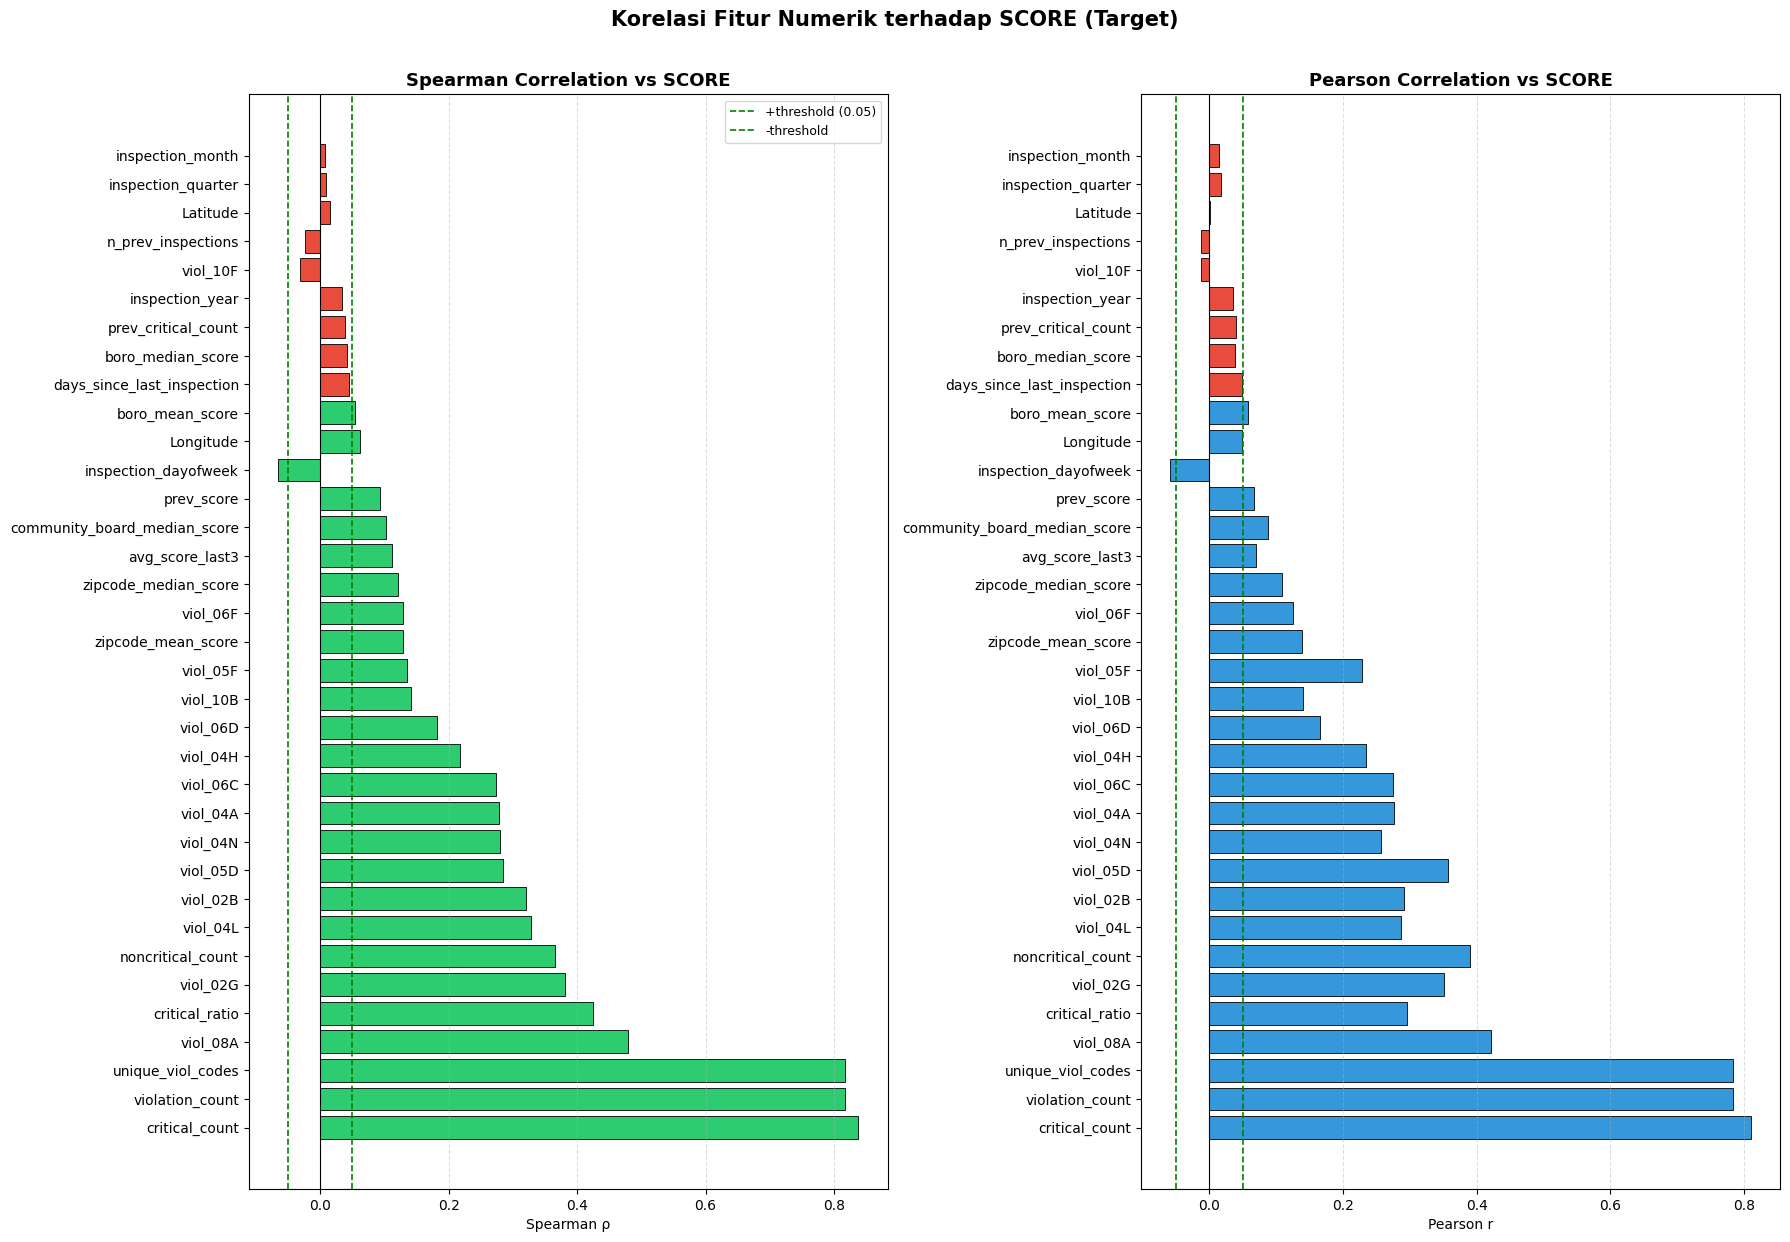


Fitur LEMAH (akan dipertimbangkan untuk di-drop):
['days_since_last_inspection', 'boro_median_score', 'prev_critical_count', 'inspection_year', 'viol_10F', 'n_prev_inspections', 'Latitude', 'inspection_quarter', 'inspection_month']

Fitur KUAT (dipertahankan):
['critical_count', 'violation_count', 'unique_viol_codes', 'viol_08A', 'critical_ratio', 'viol_02G', 'noncritical_count', 'viol_04L', 'viol_02B', 'viol_05D', 'viol_04N', 'viol_04A', 'viol_06C', 'viol_04H', 'viol_06D', 'viol_10B', 'viol_05F', 'zipcode_mean_score', 'viol_06F', 'zipcode_median_score', 'avg_score_last3', 'community_board_median_score', 'prev_score', 'inspection_dayofweek', 'Longitude', 'boro_mean_score']


In [290]:
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(df_corr) * 0.35)))

colors_sp = ["#2ecc71" if k else "#e74c3c" for k in df_corr["keep"]]
axes[0].barh(df_corr["feature"], df_corr["spearman_r"], color=colors_sp, edgecolor="black", linewidth=0.6)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].axvline( SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2, label=f"+threshold ({SPEARMAN_THRESHOLD})")
axes[0].axvline(-SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2, label=f"-threshold")
axes[0].set_title("Spearman Correlation vs SCORE", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Spearman ρ")
axes[0].legend(fontsize=9)
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

colors_pe = ["#3498db" if k else "#e74c3c" for k in df_corr["keep"]]
axes[1].barh(df_corr["feature"], df_corr["pearson_r"], color=colors_pe, edgecolor="black", linewidth=0.6)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].axvline( SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2)
axes[1].axvline(-SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2)
axes[1].set_title("Pearson Correlation vs SCORE", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Pearson r")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Korelasi Fitur Numerik terhadap SCORE (Target)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nFitur LEMAH (akan dipertimbangkan untuk di-drop):")
print(df_corr[~df_corr["keep"]]["feature"].tolist())
print("\nFitur KUAT (dipertahankan):")
print(df_corr[df_corr["keep"]]["feature"].tolist())


In [291]:
cat_cols_to_check = [
    "BORO", "CUISINE_DESCRIPTION", "INSPECTION TYPE", "ZIPCODE", "Community_Board"
]

eta_results = []
for col in cat_cols_to_check:
    tmp = df_base[[col, "SCORE"]].dropna().copy()
    tmp[col] = tmp[col].astype(str)

    groups = [grp["SCORE"].values for _, grp in tmp.groupby(col) if len(grp) >= 5]
    if len(groups) < 2:
        continue

    f_stat, p_val = stats.f_oneway(*groups)

    grand_mean = tmp["SCORE"].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total   = sum((tmp["SCORE"] - grand_mean)**2)
    eta_sq     = ss_between / ss_total if ss_total > 0 else 0

    eta_results.append({
        "feature":    col,
        "f_stat":     round(f_stat, 4),
        "p_value":    round(p_val, 6),
        "eta_squared": round(eta_sq, 6),
        "n_categories": tmp[col].nunique(),
    })

df_eta = (
    pd.DataFrame(eta_results)
    .sort_values("eta_squared", ascending=False)
    .reset_index(drop=True)
)

ETA_THRESHOLD = 0.01
df_eta["keep"] = df_eta["eta_squared"] >= ETA_THRESHOLD
df_eta["effect_size"] = df_eta["eta_squared"].apply(
    lambda x: "Large (η²≥0.14)" if x >= 0.14
    else "Medium (η²≥0.06)" if x >= 0.06
    else "Small (η²≥0.01)" if x >= 0.01
    else "Negligible"
)

print(f"Total fitur kategorikal diperiksa: {len(df_eta)}")
print()
df_eta


Total fitur kategorikal diperiksa: 5



,feature,f_stat,p_value,eta_squared,n_categories,keep,effect_size
0,CUISINE_DESCRIPTION,112.4816,0.0,0.023922,16,True,Small (η²≥0.01)
1,INSPECTION TYPE,288.1229,0.0,0.020494,6,True,Small (η²≥0.01)
2,ZIPCODE,6.5192,0.0,0.018733,230,True,Small (η²≥0.01)
3,Community_Board,11.8809,0.0,0.011102,70,True,Small (η²≥0.01)
4,BORO,45.3612,0.0,0.003283,6,False,Negligible


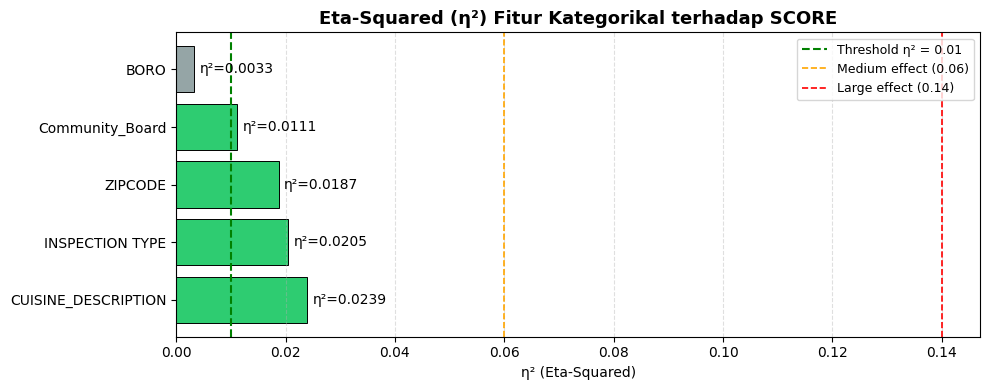

In [292]:
fig, ax = plt.subplots(figsize=(10, max(4, len(df_eta) * 0.7)))

color_map = {
    "Large (η²≥0.14)":   "#c0392b",
    "Medium (η²≥0.06)":  "#e67e22",
    "Small (η²≥0.01)":   "#2ecc71",
    "Negligible":         "#95a5a6",
}
bar_colors = [color_map[e] for e in df_eta["effect_size"]]

bars = ax.barh(df_eta["feature"], df_eta["eta_squared"],
               color=bar_colors, edgecolor="black", linewidth=0.7)
ax.axvline(ETA_THRESHOLD, color="green", linestyle="--", linewidth=1.5,
           label=f"Threshold η² = {ETA_THRESHOLD}")
ax.axvline(0.06, color="orange", linestyle="--", linewidth=1.2, label="Medium effect (0.06)")
ax.axvline(0.14, color="red",    linestyle="--", linewidth=1.2, label="Large effect (0.14)")

for bar, val in zip(bars, df_eta["eta_squared"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"η²={val:.4f}", va="center", fontsize=10)

ax.set_title("Eta-Squared (η²) Fitur Kategorikal terhadap SCORE", fontsize=13, fontweight="bold")
ax.set_xlabel("η² (Eta-Squared)")
ax.legend(fontsize=9)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [293]:
print("=" * 65)
print("  REKOMENDASI FITUR BERDASARKAN KORELASI")
print("=" * 65)

keep_num  = df_corr[df_corr["keep"]]["feature"].tolist()
drop_num  = df_corr[~df_corr["keep"]]["feature"].tolist()
keep_cat  = df_eta[df_eta["keep"]]["feature"].tolist()
drop_cat  = df_eta[~df_eta["keep"]]["feature"].tolist()

print(f"\nFitur NUMERIK dipertahankan ({len(keep_num)}):")
for f in keep_num:
    row = df_corr[df_corr["feature"] == f].iloc[0]
    print(f"   {f:<40} ρ={row['spearman_r']:+.4f}  p={row['spearman_p']:.4f}")

print(f"\nFitur NUMERIK lemah — pertimbangkan DROP ({len(drop_num)}):")
for f in drop_num:
    row = df_corr[df_corr["feature"] == f].iloc[0]
    print(f"   {f:<40} ρ={row['spearman_r']:+.4f}  p={row['spearman_p']:.4f}")

print(f"\nFitur KATEGORIKAL dipertahankan ({len(keep_cat)}):")
for f in keep_cat:
    row = df_eta[df_eta["feature"] == f].iloc[0]
    print(f"   {f:<40} η²={row['eta_squared']:.4f}  ({row['effect_size']})")

print(f"\nFitur KATEGORIKAL lemah — pertimbangkan DROP ({len(drop_cat)}):")
for f in drop_cat:
    row = df_eta[df_eta["feature"] == f].iloc[0]
    print(f"   {f:<40} η²={row['eta_squared']:.4f}  ({row['effect_size']})")

recommended_num = keep_num
recommended_cat = keep_cat
print(f"\n{'='*65}")
print(f"  TOTAL FITUR DIREKOMENDASIKAN: {len(recommended_num) + len(recommended_cat)}")
print(f"  Numerik: {len(recommended_num)}  |  Kategorikal: {len(recommended_cat)}")
print(f"{'='*65}")


  REKOMENDASI FITUR BERDASARKAN KORELASI

Fitur NUMERIK dipertahankan (26):
   critical_count                           ρ=+0.8381  p=0.0000
   violation_count                          ρ=+0.8176  p=0.0000
   unique_viol_codes                        ρ=+0.8176  p=0.0000
   viol_08A                                 ρ=+0.4795  p=0.0000
   critical_ratio                           ρ=+0.4245  p=0.0000
   viol_02G                                 ρ=+0.3808  p=0.0000
   noncritical_count                        ρ=+0.3651  p=0.0000
   viol_04L                                 ρ=+0.3289  p=0.0000
   viol_02B                                 ρ=+0.3208  p=0.0000
   viol_05D                                 ρ=+0.2845  p=0.0000
   viol_04N                                 ρ=+0.2806  p=0.0000
   viol_04A                                 ρ=+0.2784  p=0.0000
   viol_06C                                 ρ=+0.2740  p=0.0000
   viol_04H                                 ρ=+0.2171  p=0.0000
   viol_06D                 

In [294]:
FINAL_NUM_FEATURES = recommended_num
FINAL_CAT_FEATURES = recommended_cat

print("Daftar fitur numerik final:")
print(FINAL_NUM_FEATURES)
print()
print("Daftar fitur kategorikal final:")
print(FINAL_CAT_FEATURES)


Daftar fitur numerik final:
['critical_count', 'violation_count', 'unique_viol_codes', 'viol_08A', 'critical_ratio', 'viol_02G', 'noncritical_count', 'viol_04L', 'viol_02B', 'viol_05D', 'viol_04N', 'viol_04A', 'viol_06C', 'viol_04H', 'viol_06D', 'viol_10B', 'viol_05F', 'zipcode_mean_score', 'viol_06F', 'zipcode_median_score', 'avg_score_last3', 'community_board_median_score', 'prev_score', 'inspection_dayofweek', 'Longitude', 'boro_mean_score']

Daftar fitur kategorikal final:
['CUISINE_DESCRIPTION', 'INSPECTION TYPE', 'ZIPCODE', 'Community_Board']


## Step 5 - Apply Drop Fitur Lemah Berdasarkan Correlation Analysis ##

**Keputusan drop berdasarkan hasil korelasi:**

| Fitur | Alasan Drop |
|---|---|
| `inspection_month`, `inspection_quarter`, `inspection_year` | ρ < 0.04, tidak ada pola temporal signifikan |
| `inspection_dayofweek` | ρ = -0.066, lolos tipis tapi makna meragukan |
| `Latitude` | ρ = 0.016, sangat lemah — Longitude lebih diskriminatif |
| `BORO` | η² = 0.003 (Negligible) — sudah ter-capture di `boro_mean_score` |
| `boro_median_score` | ρ = 0.042, di bawah threshold — pakai `boro_mean_score` saja |
| `prev_critical_count` | ρ = 0.038, redundan dengan `critical_count` saat ini |
| `n_prev_inspections` | ρ = -0.023, tidak prediktif |
| `days_since_last_inspection` | ρ = 0.045, borderline dan tidak informatif |
| `viol_10F` | ρ = -0.031, frekuensi tinggi di EDA tapi tidak diskriminatif untuk score |
| `ever_had_critical` | Boolean lemah, sudah di-cover oleh `has_critical` & `critical_count` |


In [295]:
cols_to_drop = [
    "inspection_month",
    "inspection_quarter",
    "inspection_year",
    "inspection_dayofweek",
    "Latitude",
    "boro_median_score",
    "BORO",
    "prev_critical_count",
    "n_prev_inspections",
    "days_since_last_inspection",
    "ever_had_critical",
    "viol_10F",
]

cols_to_drop_exist = [c for c in cols_to_drop if c in df_base.columns]
cols_not_found     = [c for c in cols_to_drop if c not in df_base.columns]

df_base = df_base.drop(columns=cols_to_drop_exist)

print(f"Kolom di-drop ({len(cols_to_drop_exist)}): {cols_to_drop_exist}")
if cols_not_found:
    print(f"Tidak ditemukan (skip): {cols_not_found}")
print(f"\nShape df_base setelah drop: {df_base.shape}")
print(f"\nKolom tersisa ({len(df_base.columns)}):")
print(df_base.columns.tolist())


Kolom di-drop (12): ['inspection_month', 'inspection_quarter', 'inspection_year', 'inspection_dayofweek', 'Latitude', 'boro_median_score', 'BORO', 'prev_critical_count', 'n_prev_inspections', 'days_since_last_inspection', 'ever_had_critical', 'viol_10F']

Shape df_base setelah drop: (68860, 33)

Kolom tersisa (33):
['CAMIS', 'INSPECTION DATE', 'SCORE', 'CUISINE_DESCRIPTION', 'ZIPCODE', 'Longitude', 'Community_Board', 'INSPECTION TYPE', 'violation_count', 'unique_viol_codes', 'critical_count', 'noncritical_count', 'has_critical', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04H', 'viol_04L', 'viol_04N', 'viol_05D', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06F', 'viol_08A', 'viol_10B', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_median_score', 'zipcode_mean_score', 'community_board_median_score']


## Step 6 - Advanced Preprocessing: Encoding Variabel Kategorikal ##

**Strategi encoding berdasarkan hasil korelasi:**

| Fitur | Strategi | Alasan |
|---|---|---|
| `INSPECTION TYPE` | **One-Hot Encoding** | 6 kategori (top 5 + Other), η²=0.021 |
| `ZIPCODE` | **Drop raw** → sudah ada `zipcode_mean_score` & `zipcode_median_score` | Ratusan kategori, encoding numeriknya lebih informatif |
| `Community_Board` | **Drop raw** → sudah ada `community_board_median_score` | Sama seperti ZIPCODE |

**Catatan:** `CAMIS` dan `INSPECTION DATE` adalah identifier — tidak ikut di-encode, di-drop sebelum modeling.


In [296]:
ohe_cols = ["INSPECTION TYPE"]

df_encoded = pd.get_dummies(
    df_base,
    columns=ohe_cols,
    prefix={"INSPECTION TYPE": "instype"},
    drop_first=False,   
    dtype=int           
)

print(f"Shape sebelum OHE: {df_base.shape}")
print(f"Shape setelah OHE: {df_encoded.shape}")
print(f"Kolom baru dari OHE ({df_encoded.shape[1] - df_base.shape[1]}):")
new_ohe_cols = [c for c in df_encoded.columns if c.startswith("instype_")]
print(new_ohe_cols)

Shape sebelum OHE: (68860, 33)
Shape setelah OHE: (68860, 38)
Kolom baru dari OHE (5):
['instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening Inspection', 'instype_Other', 'instype_Pre-permit (Operational) / Initial Inspection', 'instype_Pre-permit (Operational) / Re-inspection']


In [297]:
raw_cat_to_drop = ["ZIPCODE", "Community_Board", "CUISINE_DESCRIPTION"]
id_cols         = ["CAMIS", "INSPECTION DATE"]

df_ids = df_encoded[id_cols].copy()

df_encoded = df_encoded.drop(
    columns=[c for c in raw_cat_to_drop + id_cols if c in df_encoded.columns]
)

print(f"Shape df_encoded setelah drop kolom raw: {df_encoded.shape}")
print()
print("Kolom final df_encoded:")
print(df_encoded.columns.tolist())

Shape df_encoded setelah drop kolom raw: (68860, 33)

Kolom final df_encoded:
['SCORE', 'Longitude', 'violation_count', 'unique_viol_codes', 'critical_count', 'noncritical_count', 'has_critical', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04H', 'viol_04L', 'viol_04N', 'viol_05D', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06F', 'viol_08A', 'viol_10B', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_median_score', 'zipcode_mean_score', 'community_board_median_score', 'instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening Inspection', 'instype_Other', 'instype_Pre-permit (Operational) / Initial Inspection', 'instype_Pre-permit (Operational) / Re-inspection']


In [298]:
df_encoded["has_critical"] = df_encoded["has_critical"].astype(int)

non_numeric = df_encoded.select_dtypes(exclude="number").columns.tolist()

if non_numeric:
    print(f"Masih ada kolom non-numerik: {non_numeric}")
    print("Perlu ditangani sebelum modeling!")
else:
    print("Semua kolom sudah numerik — df_encoded siap untuk tahap scaling & modeling")

print(f"\nShape final: {df_encoded.shape}")
print(f"Missing values total: {df_encoded.isna().sum().sum()}")
print()
print("=== Dtypes summary ===")
print(df_encoded.dtypes.value_counts())
print()
print("=== Preview 5 baris pertama ===")
df_encoded.head()

Semua kolom sudah numerik — df_encoded siap untuk tahap scaling & modeling

Shape final: (68860, 33)
Missing values total: 0

=== Dtypes summary ===
float64    26
int64       7
Name: count, dtype: int64

=== Preview 5 baris pertama ===


,SCORE,Longitude,violation_count,unique_viol_codes,critical_count,noncritical_count,has_critical,critical_ratio,viol_02B,viol_02G,viol_04A,viol_04H,viol_04L,viol_04N,viol_05D,viol_05F,viol_06C,viol_06D,viol_06F,viol_08A,viol_10B,prev_score,avg_score_last3,boro_mean_score,zipcode_median_score,zipcode_mean_score,community_board_median_score,instype_Cycle Inspection / Initial Inspection,instype_Cycle Inspection / Re-inspection,instype_Cycle Inspection / Reopening Inspection,instype_Other,instype_Pre-permit (Operational) / Initial Inspection,instype_Pre-permit (Operational) / Re-inspection
0,38.0,-73.855972,3.0,3.0,2.0,1.0,1,0.666667,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13.000000,13.000000,17.723636,12.0,16.968326,13.0,1,0,0,0,0,0
1,12.0,-73.855972,3.0,3.0,1.0,2.0,1,0.333333,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.663562,3.663562,17.723636,12.0,16.968326,13.0,0,1,0,0,0,0
2,10.0,-73.855972,3.0,3.0,1.0,2.0,1,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.564949,3.258097,17.723636,12.0,16.968326,13.0,1,0,0,0,0,0
3,7.0,-73.855972,2.0,2.0,1.0,1.0,1,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.397895,3.044522,17.723636,12.0,16.968326,13.0,1,0,0,0,0,0
4,10.0,-73.984310,2.0,2.0,2.0,0.0,1,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,13.000000,13.000000,17.384430,12.0,16.972575,12.0,1,0,0,0,0,0


In [299]:
from scipy.stats.mstats import winsorize

cols_to_winsorize = [
    "violation_count", "critical_count", "noncritical_count",
    "unique_viol_codes", "critical_ratio"
]

for col in cols_to_winsorize:
    upper = df_encoded[col].quantile(0.99)
    df_encoded[col] = df_encoded[col].clip(upper=upper)
    print(f"{col:<25} capped at P99 = {upper:.2f}")

print("\nWinsorize fitur numerik selesai")

violation_count           capped at P99 = 10.00
critical_count            capped at P99 = 7.00
noncritical_count         capped at P99 = 4.00
unique_viol_codes         capped at P99 = 10.00
critical_ratio            capped at P99 = 1.00

Winsorize fitur numerik selesai


In [300]:
skew_df = (
    df_encoded[[c for c in df_encoded.columns
                if not any(c.startswith(p) for p in 
                          ["cuisine_", "instype_", "viol_"])
                and c not in ["has_critical", "SCORE"]]]
    .skew()
    .abs()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", 0: "abs_skewness"})
)

skew_df["perlu_log"] = skew_df["abs_skewness"] > 1.0  

print(skew_df.to_string(index=False))

                     feature  abs_skewness  perlu_log
        zipcode_median_score      2.384295       True
community_board_median_score      2.261785       True
              critical_count      1.120576       True
             violation_count      1.030928       True
           unique_viol_codes      1.030928       True
             boro_mean_score      0.784905      False
           noncritical_count      0.544258      False
             avg_score_last3      0.401437      False
                  prev_score      0.384908      False
                   Longitude      0.206318      False
          zipcode_mean_score      0.149565      False
              critical_ratio      0.129132      False


In [301]:
for col in ["critical_count", "violation_count", "unique_viol_codes"]:
    df_encoded[col] = np.log1p(df_encoded[col])
    print(f"{col} → log1p applied")

critical_count → log1p applied
violation_count → log1p applied
unique_viol_codes → log1p applied


Total fitur masuk modeling: 32
Fitur dengan |ρ| ≥ 0.05: 29
Fitur dengan |ρ| < 0.05: 3



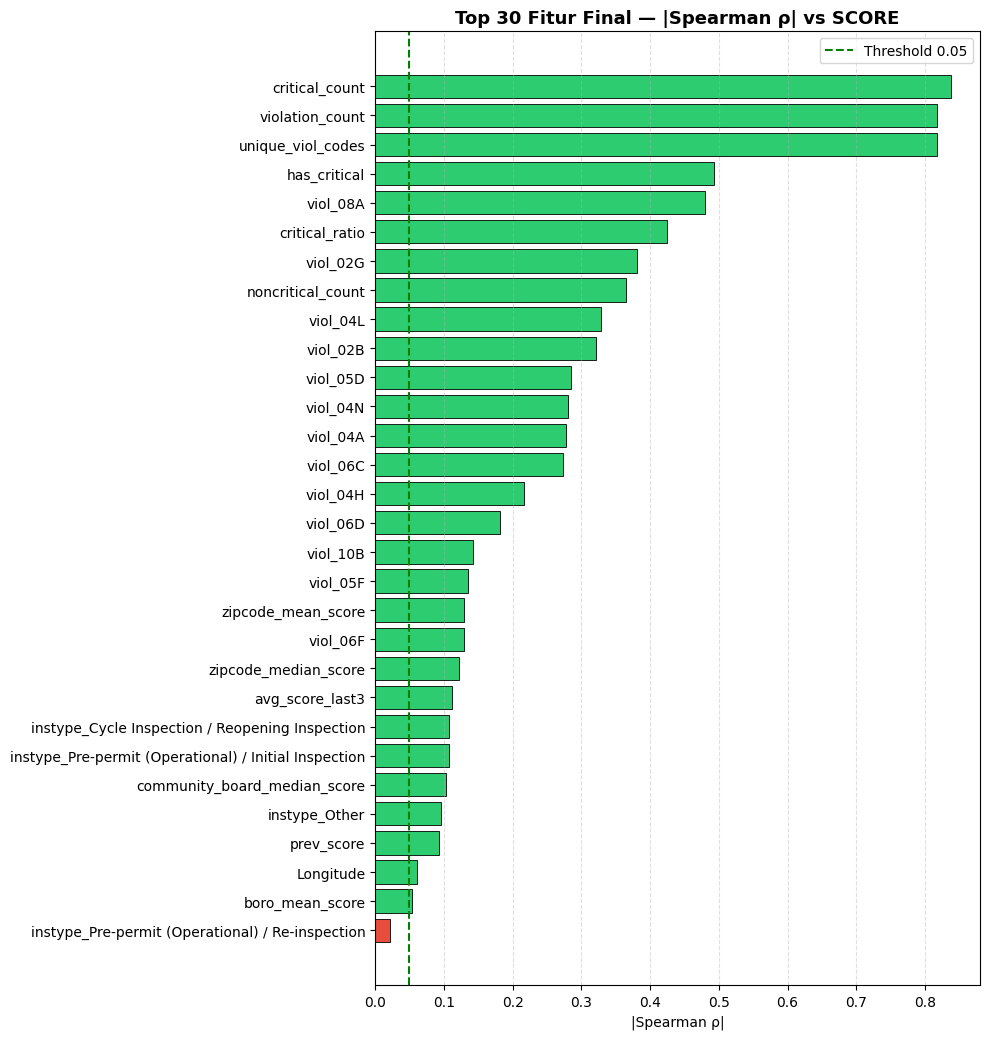


=== Top 10 fitur paling prediktif ===
          feature  abs_spearman_rho
   critical_count          0.838132
  violation_count          0.817547
unique_viol_codes          0.817547
     has_critical          0.492786
         viol_08A          0.479486
   critical_ratio          0.424459
         viol_02G          0.380793
noncritical_count          0.364986
         viol_04L          0.328939
         viol_02B          0.320815


In [302]:
final_corr = (
    df_encoded.corr(method="spearman")["SCORE"]
    .drop("SCORE")
    .abs()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", "SCORE": "abs_spearman_rho"})
)

print(f"Total fitur masuk modeling: {len(final_corr)}")
print(f"Fitur dengan |ρ| ≥ 0.05: {(final_corr['abs_spearman_rho'] >= 0.05).sum()}")
print(f"Fitur dengan |ρ| < 0.05: {(final_corr['abs_spearman_rho'] < 0.05).sum()}")
print()

top_n = min(30, len(final_corr))
plot_df = final_corr.head(top_n)

fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.35)))
colors = ["#2ecc71" if v >= 0.05 else "#e74c3c" for v in plot_df["abs_spearman_rho"]]
ax.barh(plot_df["feature"], plot_df["abs_spearman_rho"],
        color=colors, edgecolor="black", linewidth=0.6)
ax.axvline(0.05, color="green", linestyle="--", linewidth=1.5, label="Threshold 0.05")
ax.set_title(f"Top {top_n} Fitur Final — |Spearman ρ| vs SCORE", fontsize=13, fontweight="bold")
ax.set_xlabel("|Spearman ρ|")
ax.legend()
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n=== Top 10 fitur paling prediktif ===")
print(final_corr.head(10).to_string(index=False))

## Step 7 - Advanced Preprocessing: Handling Outlier pada SCORE ##

**Konteks dari EDA:**
- Distribusi SCORE **right-skewed** — mayoritas score berkumpul di 0–25, ada ekor panjang ke kanan
- Outlier score tinggi tetap **informatif** — bukan noise, melainkan inspeksi berisiko tinggi

**Strategi: Winsorize dulu → lalu Log1p Transform**

| Teknik | Fungsi | Urutan |
|---|---|---|
| **Winsorize (P99)** | Potong nilai ekstrem agar tidak mendominasi log scale | 1️⃣ |
| **Log1p Transform** | Perbaiki right-skewness distribusi → mendekati normal | 2️⃣ |

Mengapa log1p dan bukan log biasa? Karena SCORE bisa bernilai **0** → `log(0) = -inf`.
`log1p(x) = log(x + 1)` aman untuk nilai 0.

⚠️ **Konsekuensi:** Prediksi model akan dalam skala log → saat evaluasi dan interpretasi,
hasil prediksi harus dikembalikan ke skala asli dengan `np.expm1(y_pred)`.


=== Statistik SCORE (sebelum handling) ===
Min    : 0.0
Q1     : 9.0
Median : 13.0
Mean   : 18.12
Q3     : 24.0
P95    : 47.0
P99    : 73.0
Max    : 203.0
Skewness: 2.209

Outlier (IQR): 3,628 baris (5.3%)
Outlier ekstrem (>P99=73.0): 654 baris


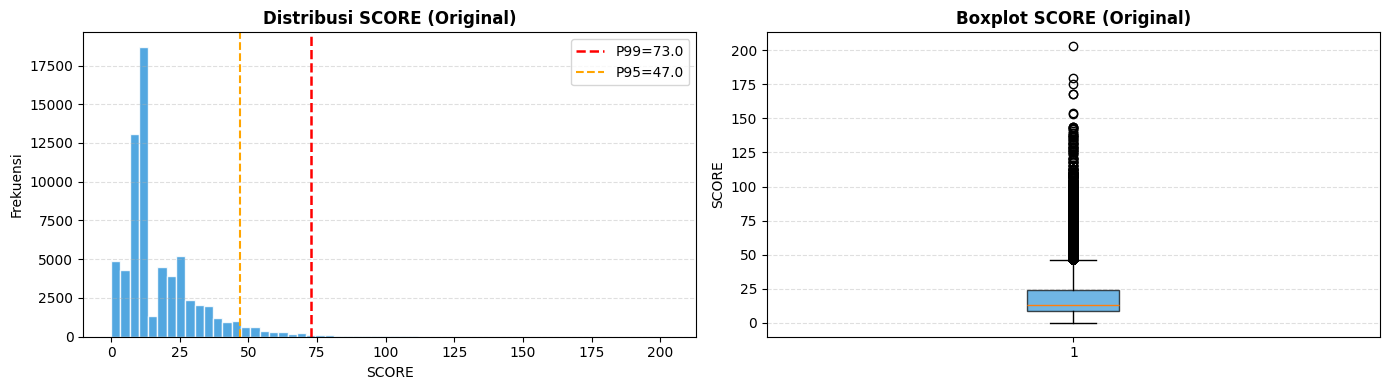

In [303]:
score = df_encoded["SCORE"]

q1  = score.quantile(0.25)
q3  = score.quantile(0.75)
iqr = q3 - q1
p99 = score.quantile(0.99)
p95 = score.quantile(0.95)

print("=== Statistik SCORE (sebelum handling) ===")
print(f"Min    : {score.min():.1f}")
print(f"Q1     : {q1:.1f}")
print(f"Median : {score.median():.1f}")
print(f"Mean   : {score.mean():.2f}")
print(f"Q3     : {q3:.1f}")
print(f"P95    : {p95:.1f}")
print(f"P99    : {p99:.1f}")
print(f"Max    : {score.max():.1f}")
print(f"Skewness: {score.skew():.3f}")
print(f"\nOutlier (IQR): {(score > q3 + 1.5*iqr).sum():,} baris ({(score > q3 + 1.5*iqr).mean()*100:.1f}%)")
print(f"Outlier ekstrem (>P99={p99:.1f}): {(score > p99).sum():,} baris")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(score, bins=60, color="#3498db", edgecolor="white", alpha=0.85)
axes[0].axvline(p99, color="red",    linestyle="--", linewidth=1.8, label=f"P99={p99:.1f}")
axes[0].axvline(p95, color="orange", linestyle="--", linewidth=1.5, label=f"P95={p95:.1f}")
axes[0].set_title("Distribusi SCORE (Original)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("SCORE"); axes[0].set_ylabel("Frekuensi")
axes[0].legend(); axes[0].grid(axis="y", linestyle="--", alpha=0.4)

axes[1].boxplot(score, vert=True, patch_artist=True, boxprops=dict(facecolor="#3498db", alpha=0.7))
axes[1].set_title("Boxplot SCORE (Original)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("SCORE"); axes[1].grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [304]:
CAP_PERCENTILE = 0.99
score_cap = df_encoded["SCORE"].quantile(CAP_PERCENTILE)
df_encoded["SCORE"] = df_encoded["SCORE"].clip(upper=score_cap)

print(f"[Winsorize] Cap di P99 = {score_cap:.1f}")
print(f"Baris yang di-cap: {(df_encoded['SCORE'] == score_cap).sum():,}")
print(f"Skewness setelah winsorize: {df_encoded['SCORE'].skew():.3f}")
print()


df_encoded["SCORE"] = np.log1p(df_encoded["SCORE"])

print(f"[Log1p] Transform diterapkan: SCORE = log(SCORE_winsorized + 1)")
print(f"Skewness setelah log1p      : {df_encoded['SCORE'].skew():.3f}")
print(f"Range SCORE sekarang        : [{df_encoded['SCORE'].min():.3f}, {df_encoded['SCORE'].max():.3f}]")
print()


[Winsorize] Cap di P99 = 73.0
Baris yang di-cap: 700
Skewness setelah winsorize: 1.621

[Log1p] Transform diterapkan: SCORE = log(SCORE_winsorized + 1)
Skewness setelah log1p      : -0.714
Range SCORE sekarang        : [0.000, 4.304]



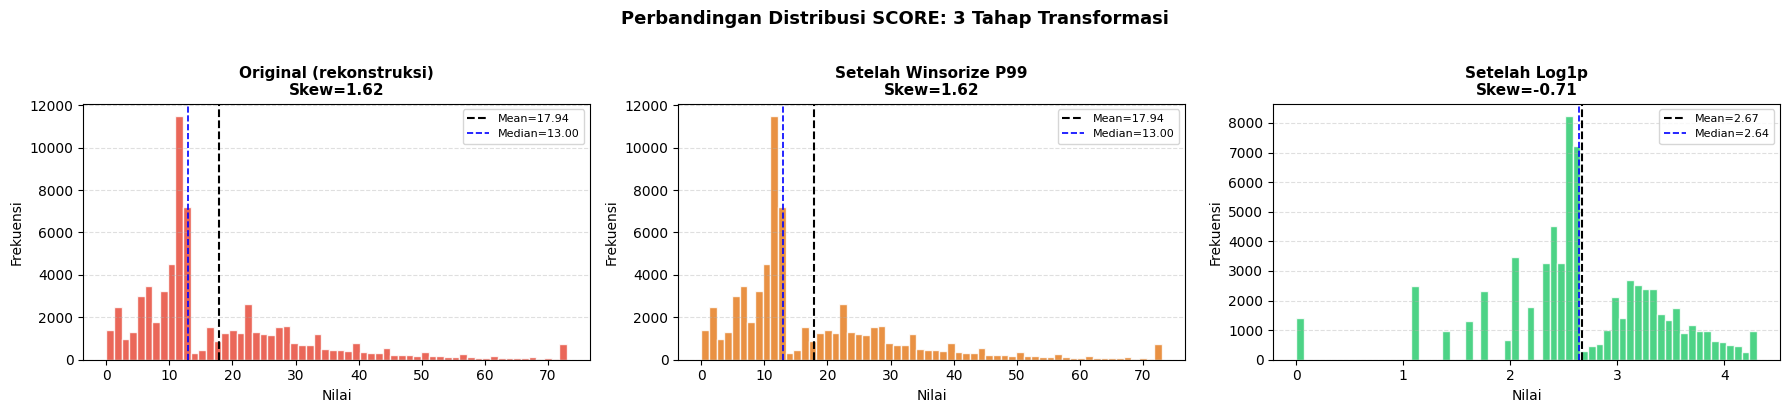

In [305]:
score_original  = df_encoded["SCORE"].apply(np.expm1).clip(upper=score_cap)  
score_winsorize = score_original 
score_log1p     = df_encoded["SCORE"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

data_stages = [
    (df_encoded["SCORE"].apply(np.expm1), "Original (rekonstruksi)", "#e74c3c"),
    (score_winsorize,                      f"Setelah Winsorize P99",   "#e67e22"),
    (score_log1p,                          "Setelah Log1p",            "#2ecc71"),
]

for ax, (data, title, color) in zip(axes, data_stages):
    ax.hist(data, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="black",  linestyle="--", linewidth=1.5,
               label=f"Mean={data.mean():.2f}")
    ax.axvline(data.median(), color="blue",   linestyle="--", linewidth=1.2,
               label=f"Median={data.median():.2f}")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Nilai"); ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_title(f"{title}\nSkew={data.skew():.2f}", fontsize=11, fontweight="bold")

plt.suptitle("Perbandingan Distribusi SCORE: 3 Tahap Transformasi",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Step 8 - Advanced Preprocessing: Train-Test Split (Temporal) ##

**Mengapa 3-Way Temporal Split (Train / Validation / Test)?**

| Set | Proporsi | Fungsi |
|---|---|---|
| **Train** | 70% | Melatih model |
| **Validation** | 15% | Tuning hyperparameter, pilih model terbaik |
| **Test** | 15% | Evaluasi final — **hanya disentuh sekali di akhir** |

Kalau hanya pakai train/test dan tuning dilakukan berdasarkan test set → test set "bocor" ke proses
training secara tidak langsung → hasil evaluasi **overly optimistic**, tidak mencerminkan performa di data baru.

Split tetap **temporal** dan berurutan karena data ini time-series inspeksi:
```
[────── Train (70%) ──────────][── Val (15%) ──][── Test (15%) ──]
 terlama                                                  terbaru
```

⚠️  **Target encoding di-refit dari train saja**, lalu di-apply ke val dan test.


In [306]:
df_split = df_encoded.copy()
df_split["INSPECTION DATE"] = pd.to_datetime(df_ids["INSPECTION DATE"].values)
df_split["CAMIS"]           = df_ids["CAMIS"].values
df_split = df_split.sort_values("INSPECTION DATE").reset_index(drop=True)

n = len(df_split)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_split.iloc[:train_end].copy()
val_df   = df_split.iloc[train_end:val_end].copy()
test_df  = df_split.iloc[val_end:].copy()

print(f"Total data       : {n:,}")
print(f"\nTrain  : {len(train_df):,} baris ({len(train_df)/n*100:.1f}%)")
print(f"  Periode: {train_df['INSPECTION DATE'].min().date()} → {train_df['INSPECTION DATE'].max().date()}")
print(f"\nVal    : {len(val_df):,} baris ({len(val_df)/n*100:.1f}%)")
print(f"  Periode: {val_df['INSPECTION DATE'].min().date()} → {val_df['INSPECTION DATE'].max().date()}")
print(f"\nTest   : {len(test_df):,} baris ({len(test_df)/n*100:.1f}%)")
print(f"  Periode: {test_df['INSPECTION DATE'].min().date()} → {test_df['INSPECTION DATE'].max().date()}")

Total data       : 68,860

Train  : 48,202 baris (70.0%)
  Periode: 2023-03-03 → 2025-05-09

Val    : 10,329 baris (15.0%)
  Periode: 2025-05-09 → 2025-10-07

Test   : 10,329 baris (15.0%)
  Periode: 2025-10-07 → 2026-02-28


**Target Encoding untuk Cuisine Description pada masing-masing train, val, dan test**

In [307]:
camis_cuisine = (
    df_ins[["CAMIS", "CUISINE_DESCRIPTION"]]
    .astype(str)
    .groupby("CAMIS")
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

for df_ in [train_df, val_df, test_df]:
    df_["CAMIS"] = df_["CAMIS"].astype(str)

camis_to_cuisine = camis_cuisine.set_index("CAMIS")["CUISINE_DESCRIPTION"]
train_df["CUISINE_DESCRIPTION"] = train_df["CAMIS"].map(camis_to_cuisine)
val_df["CUISINE_DESCRIPTION"]   = val_df["CAMIS"].map(camis_to_cuisine)
test_df["CUISINE_DESCRIPTION"]  = test_df["CAMIS"].map(camis_to_cuisine)

global_median = train_df["SCORE"].median()
cuisine_mean  = train_df.groupby("CUISINE_DESCRIPTION")["SCORE"].mean().to_dict()

for df_, X_ in [(train_df, X_train), (val_df, X_val), (test_df, X_test)]:
    X_["cuisine_encoded"] = df_["CUISINE_DESCRIPTION"].map(cuisine_mean).fillna(global_median)

for df_ in [train_df, val_df, test_df]:
    df_.drop(columns=["CUISINE_DESCRIPTION"], errors="ignore", inplace=True)

print("✅ Target encoding CUISINE_DESCRIPTION selesai")
print(f"Jumlah kategori cuisine : {len(cuisine_mean)}")
print(f"Sample nilai encoding   : {dict(list(cuisine_mean.items())[:5])}")

✅ Target encoding CUISINE_DESCRIPTION selesai
Jumlah kategori cuisine : 90
Sample nilai encoding   : {'Afghan': 2.833123504308041, 'African': 2.98006820811021, 'American': 2.588143369693703, 'Armenian': 2.802479903522276, 'Asian/Asian Fusion': 2.848377820941733}


In [308]:
te_map = {
    "zipcode_mean_score":            ("ZIPCODE",         "mean"),
    "zipcode_median_score":          ("ZIPCODE",         "median"),
    "boro_mean_score":               ("BORO",            "mean"),
    "community_board_median_score":  ("Community_Board", "median"),
}

camis_geo = (
    df_ins[["CAMIS", "ZIPCODE", "BORO", "Community_Board"]]
    .copy()
    .astype(str)
    .replace("nan", pd.NA)        
    .dropna(subset=["CAMIS"])     
    .groupby("CAMIS", as_index=False)
    .first()                    
)

for df_ in [train_df, val_df, test_df]:
    df_["CAMIS"] = df_["CAMIS"].astype(str)

for geo_col in ["ZIPCODE", "BORO", "Community_Board"]:
    camis_to_geo = camis_geo.set_index("CAMIS")[geo_col]
    for df_ in [train_df, val_df, test_df]:
        df_[geo_col] = df_["CAMIS"].map(camis_to_geo)

global_median_train = train_df["SCORE"].median()

for new_col, (geo_col, agg_fn) in te_map.items():
    if new_col not in train_df.columns:
        continue
    stats_dict = (
        train_df.dropna(subset=[geo_col])
        .groupby(geo_col)["SCORE"]
        .agg(agg_fn)
        .to_dict()
    )
    for df_ in [train_df, val_df, test_df]:
        df_[new_col] = df_[geo_col].map(stats_dict).fillna(global_median_train)

geo_temp_cols = ["ZIPCODE", "BORO", "Community_Board"]
for df_ in [train_df, val_df, test_df]:
    df_.drop(columns=geo_temp_cols, errors="ignore", inplace=True)

print("\u2705 Target encoding di-refit dari train set saja, applied ke val & test")
print(f"\nTrain: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}")


✅ Target encoding di-refit dari train set saja, applied ke val & test

Train: (48202, 35) | Val: (10329, 35) | Test: (10329, 35)


In [309]:
drop_final = ["INSPECTION DATE", "CAMIS"]

X_train = train_df.drop(columns=drop_final + ["SCORE"], errors="ignore")
y_train = train_df["SCORE"]

X_val   = val_df.drop(columns=drop_final + ["SCORE"], errors="ignore")
y_val   = val_df["SCORE"]

X_test  = test_df.drop(columns=drop_final + ["SCORE"], errors="ignore")
y_test  = test_df["SCORE"]

print("=" * 55)
print("  HASIL AKHIR PREPROCESSING")
print("=" * 55)
print(f"X_train : {X_train.shape}  | y mean={y_train.mean():.3f}, std={y_train.std():.3f}")
print(f"X_val   : {X_val.shape}   | y mean={y_val.mean():.3f}, std={y_val.std():.3f}")
print(f"X_test  : {X_test.shape}   | y mean={y_test.mean():.3f}, std={y_test.std():.3f}")
print(f"\nJumlah fitur masuk modeling: {X_train.shape[1]}")
print(f"\ny dalam skala log1p — pakai np.expm1(y_pred) saat evaluasi ke skala asli")
print(f"\nFeature list:")
print(X_train.columns.tolist())


  HASIL AKHIR PREPROCESSING
X_train : (48202, 32)  | y mean=2.667, std=0.769
X_val   : (10329, 32)   | y mean=2.673, std=0.878
X_test  : (10329, 32)   | y mean=2.704, std=0.760

Jumlah fitur masuk modeling: 32

y dalam skala log1p — pakai np.expm1(y_pred) saat evaluasi ke skala asli

Feature list:
['Longitude', 'violation_count', 'unique_viol_codes', 'critical_count', 'noncritical_count', 'has_critical', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04H', 'viol_04L', 'viol_04N', 'viol_05D', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06F', 'viol_08A', 'viol_10B', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_median_score', 'zipcode_mean_score', 'community_board_median_score', 'instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening Inspection', 'instype_Other', 'instype_Pre-permit (Operational) / Initial Inspection', 'instype_Pre-permit (Operational) / Re-inspection']


## Step 9 - Advanced Preprocessing: Feature Scaling ##

**Strategi Scaling:**

| Kolom | Scaler | Alasan |
|---|---|---|
| `SCORE` (target) | **Tidak di-scale** | Target regresi dibiarkan asli agar prediksi tetap interpretable |
| Fitur numerik kontinyu (score historis, koordinat, dll) | **RobustScaler** | Tahan terhadap outlier — menggunakan median & IQR bukan mean & std |
| Fitur count (violation_count, critical_count, dll) | **RobustScaler** | Distribusinya skewed, RobustScaler lebih aman |
| Fitur binary OHE (`cuisine_*`, `instype_*`, `viol_*`, `has_critical`) | **Tidak di-scale** | Sudah 0/1, scaling justru merusak interpretasi |

**Mengapa RobustScaler bukan StandardScaler?**
SCORE dan violation features punya outlier signifikan. StandardScaler akan terpengaruh mean & std yang terdistorsi outlier, sehingga fitur normal jadi ter-compress. RobustScaler memakai median & IQR sehingga lebih stabil.


In [310]:
from sklearn.preprocessing import RobustScaler

binary_cols = (
    [c for c in X_train.columns if c.startswith("cuisine_")]
    + [c for c in X_train.columns if c.startswith("instype_")]
    + [c for c in X_train.columns if c.startswith("viol_")]
    + ["has_critical"]
)
binary_cols = [c for c in binary_cols if c in X_train.columns]

scale_cols = [
    c for c in X_train.select_dtypes(include="number").columns
    if c not in binary_cols
]

scaler = RobustScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])   
X_val[scale_cols]   = scaler.transform(X_val[scale_cols])          
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])         

print(f"✅ RobustScaler di-fit dari train, applied ke val & test")
print(f"Kolom di-scale ({len(scale_cols)}): {scale_cols}")

✅ RobustScaler di-fit dari train, applied ke val & test
Kolom di-scale (12): ['Longitude', 'violation_count', 'unique_viol_codes', 'critical_count', 'noncritical_count', 'critical_ratio', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_median_score', 'zipcode_mean_score', 'community_board_median_score']


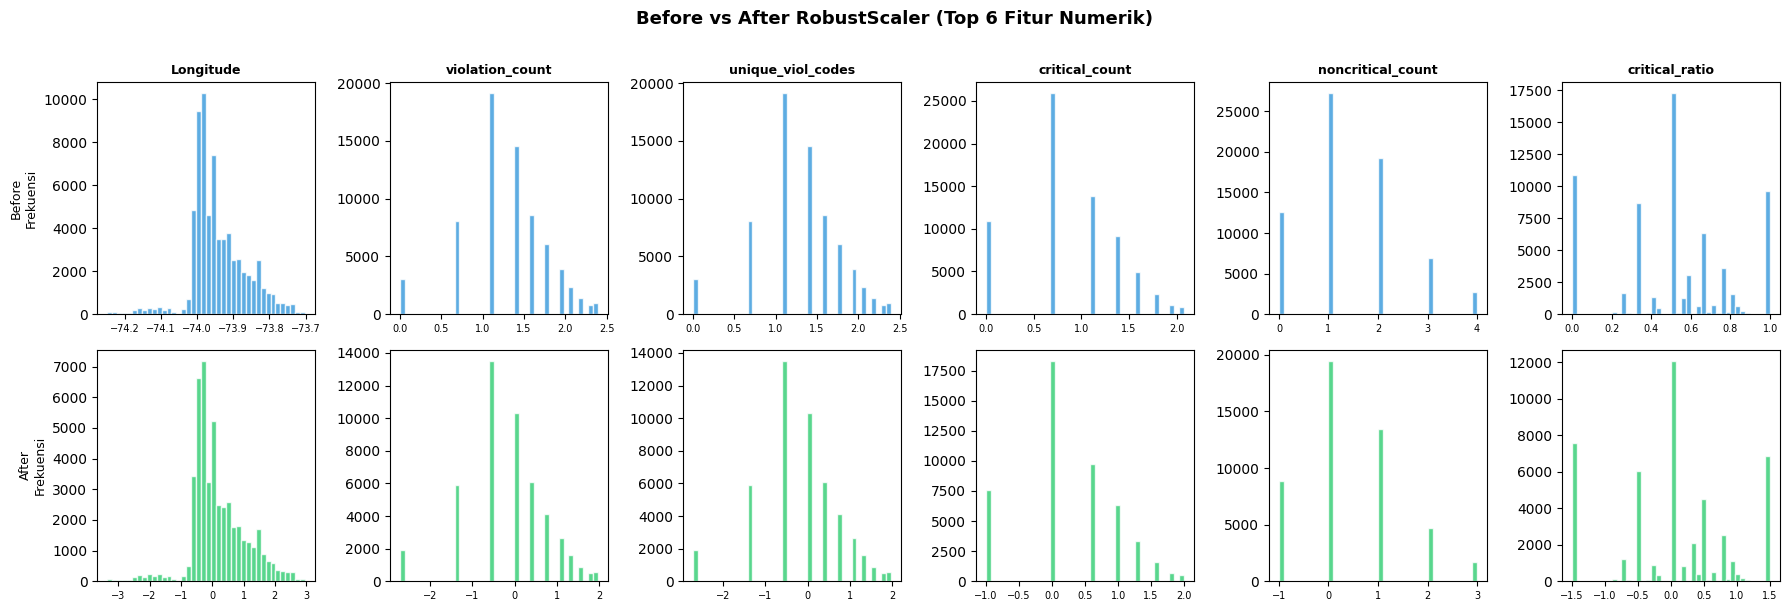

In [311]:
top6_scale = [c for c in X_train.columns if c in scale_cols][:6]

df_before = df_encoded[top6_scale].copy()

fig, axes = plt.subplots(2, len(top6_scale), figsize=(18, 6))

for i, col in enumerate(top6_scale):
    axes[0, i].hist(df_before[col].dropna(), bins=40,
                    color="#3498db", edgecolor="white", alpha=0.8)
    axes[0, i].set_title(col, fontsize=9, fontweight="bold")
    axes[0, i].tick_params(axis="x", labelsize=7)
    if i == 0: axes[0, i].set_ylabel("Before\nFrekuensi", fontsize=9)

    axes[1, i].hist(X_train[col].dropna(), bins=40,
                    color="#2ecc71", edgecolor="white", alpha=0.8)
    axes[1, i].tick_params(axis="x", labelsize=7)
    if i == 0: axes[1, i].set_ylabel("After\nFrekuensi", fontsize=9)

plt.suptitle("Before vs After RobustScaler (Top 6 Fitur Numerik)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

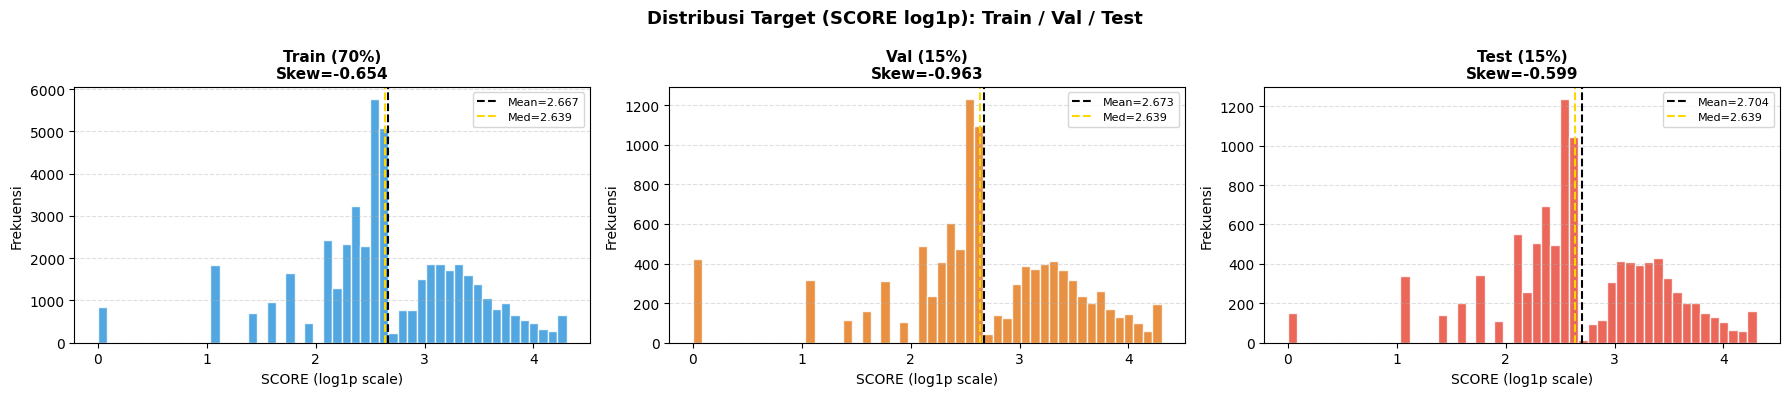

Cek: distribusi ketiga set harus mirip
Train skewness : -0.654
Val   skewness : -0.963
Test  skewness : -0.599


In [312]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sets = [
    (y_train, "Train (70%)",  "#3498db"),
    (y_val,   "Val (15%)",    "#e67e22"),
    (y_test,  "Test (15%)",   "#e74c3c"),
]

for ax, (data, label, color) in zip(axes, sets):
    ax.hist(data, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="black", linestyle="--", linewidth=1.5,
               label=f"Mean={data.mean():.3f}")
    ax.axvline(data.median(), color="gold",  linestyle="--", linewidth=1.5,
               label=f"Med={data.median():.3f}")
    ax.set_title(f"{label}\nSkew={data.skew():.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("SCORE (log1p scale)"); ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Distribusi Target (SCORE log1p): Train / Val / Test",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Cek: distribusi ketiga set harus mirip")
print(f"Train skewness : {y_train.skew():.3f}")
print(f"Val   skewness : {y_val.skew():.3f}")
print(f"Test  skewness : {y_test.skew():.3f}")


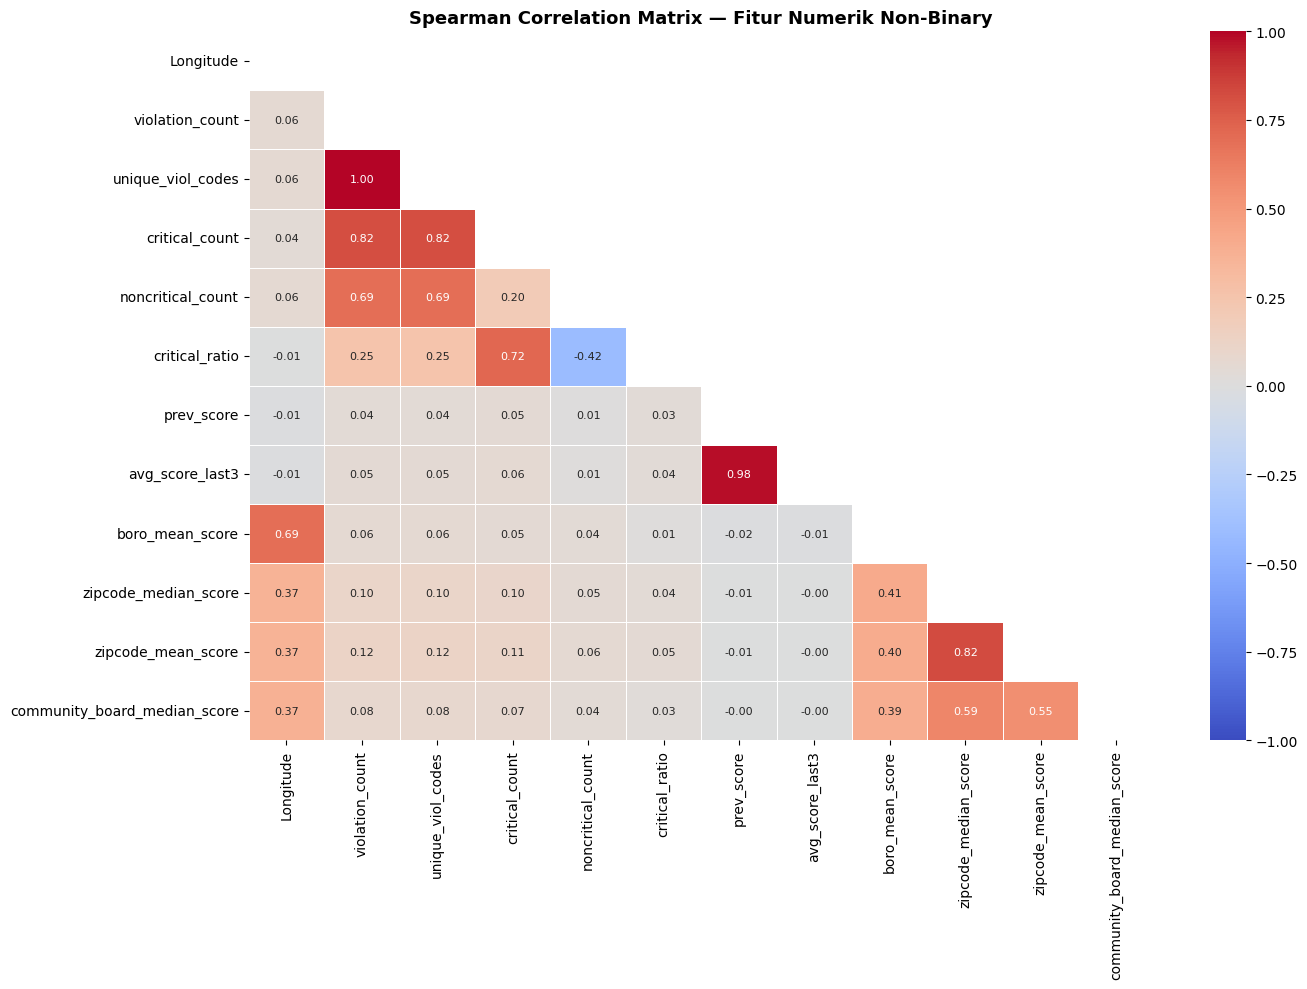

  VIF — Variance Inflation Factor
                     feature        VIF           status
             violation_count        inf   🔴 Tinggi (>10)
           unique_viol_codes        inf   🔴 Tinggi (>10)
             avg_score_last3 234.350361   🔴 Tinggi (>10)
                  prev_score 234.303073   🔴 Tinggi (>10)
              critical_count  13.224771   🔴 Tinggi (>10)
           noncritical_count   8.281899 🟠 Moderat (5-10)
              critical_ratio   5.453991 🟠 Moderat (5-10)
          zipcode_mean_score   4.669839      ✅ Aman (<5)
        zipcode_median_score   4.574282      ✅ Aman (<5)
             boro_mean_score   2.046614      ✅ Aman (<5)
                   Longitude   1.855732      ✅ Aman (<5)
community_board_median_score   1.445947      ✅ Aman (<5)

🔴 Fitur VIF > 10 : 5
🟠 Fitur VIF 5-10 : 2
✅ Fitur VIF < 5  : 5


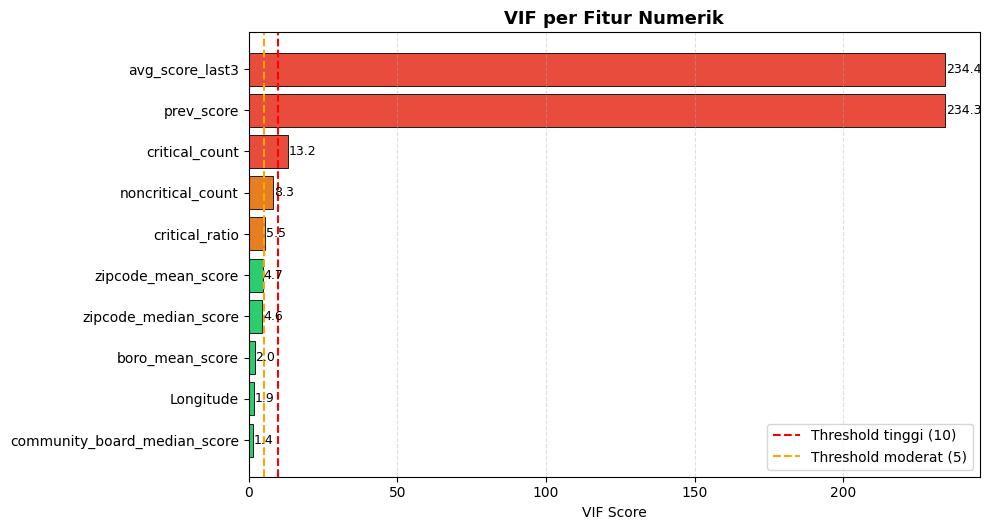

In [313]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

num_only = [c for c in X_train.columns
            if not any(c.startswith(p) for p in ["cuisine_", "instype_", "viol_"])
            and c != "has_critical"]

corr_matrix = X_train[num_only].corr(method="spearman")

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={"size": 8}
)
ax.set_title("Spearman Correlation Matrix — Fitur Numerik Non-Binary",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

X_vif = X_train[num_only].copy().dropna()

X_vif_const = add_constant(X_vif)

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif_const.values, i + 1)
            for i in range(len(X_vif.columns))]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_data["status"] = vif_data["VIF"].apply(
    lambda v: "🔴 Tinggi (>10)"   if v > 10
    else      "🟠 Moderat (5-10)" if v > 5
    else      "✅ Aman (<5)"
)

print("=" * 50)
print("  VIF — Variance Inflation Factor")
print("=" * 50)
print(vif_data.to_string(index=False))
print(f"\n🔴 Fitur VIF > 10 : {(vif_data['VIF'] > 10).sum()}")
print(f"🟠 Fitur VIF 5-10 : {((vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)).sum()}")
print(f"✅ Fitur VIF < 5  : {(vif_data['VIF'] <= 5).sum()}")

fig, ax = plt.subplots(figsize=(10, max(5, len(vif_data) * 0.45)))

colors = ["#e74c3c" if v > 10 else "#e67e22" if v > 5 else "#2ecc71"
          for v in vif_data["VIF"]]
bars = ax.barh(vif_data["feature"], vif_data["VIF"],
               color=colors, edgecolor="black", linewidth=0.6)
ax.axvline(10, color="red",    linestyle="--", linewidth=1.5, label="Threshold tinggi (10)")
ax.axvline(5,  color="orange", linestyle="--", linewidth=1.5, label="Threshold moderat (5)")

for bar, val in zip(bars, vif_data["VIF"]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", fontsize=9)

ax.set_title("VIF per Fitur Numerik", fontsize=13, fontweight="bold")
ax.set_xlabel("VIF Score")
ax.legend(); ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Eksperimen Advanced Preprocessing ##

**Tiga eksperimen yang diuji:**

| # | Eksperimen | Hipotesis |
|---|---|---|
| **1** | Imputasi historis berbasis Cuisine/BORO + `is_first_inspection` flag | Imputasi kontekstual meningkatkan akurasi untuk 39% data (inspeksi pertama) |
| **2** | Geospatial Density Features | Kepadatan restoran berisiko di sekitar lokasi lebih granular dari ZIPCODE |
| **3** | Violation Severity Weighting | Bobot per violation code menghasilkan fitur lebih diskriminatif |

**Metodologi:**
- Satu notebook dengan semua eksperimen dibandingkan sekaligus
- **Benchmark: 4 tree model** — Random Forest, XGBoost, LightGBM, CatBoost
- Geospatial density: coba semua radius (500m, 1km, 2km), pilih yang terbaik
- Anti-leakage: semua fitur baru dihitung dari **train set saja**
- Evaluasi: Val R², Val MAE, Gap overfitting


## Setup: Helper & 4 Benchmark Models ##

In [314]:
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import BallTree
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

def clean_col_name(col):
    return re.sub(r'[^A-Za-z0-9_]', '_', col)

def evaluate_quick(model, X_tr, y_tr, X_vl, y_vl, model_name, exp_name):
    y_tr_pred = np.clip(model.predict(X_tr), 0, 6)
    y_vl_pred = np.clip(model.predict(X_vl), 0, 6)

    y_tr_arr = np.array(y_tr)
    y_vl_arr = np.array(y_vl)

    # Deteksi otomatis apakah y dalam log1p scale (range 0-5)
    # atau raw scale (bisa ratusan)
    if y_vl_arr.max() > 10:
        # y masih raw → winsorize + log1p dulu
        y_tr_log = np.log1p(np.clip(y_tr_arr, 0, 73))
        y_vl_log = np.log1p(np.clip(y_vl_arr, 0, 73))
    else:
        # y sudah log1p
        y_tr_log = np.clip(y_tr_arr, 0, 6)
        y_vl_log = np.clip(y_vl_arr, 0, 6)

    return {
        "Experiment": exp_name,
        "Model":      model_name,
        "Train R²":   round(r2_score(y_tr_log, y_tr_pred), 4),
        "Val R²":     round(r2_score(y_vl_log, y_vl_pred), 4),
        "Gap R²":     round(r2_score(y_tr_log, y_tr_pred) - r2_score(y_vl_log, y_vl_pred), 4),
        "Val RMSE":   round(np.sqrt(mean_squared_error(y_vl_log, y_vl_pred)), 4),
        "Val MAE":    round(mean_absolute_error(np.expm1(y_vl_log), np.expm1(y_vl_pred)), 4),
    }

def run_all_models(X_tr, y_tr, X_vl, y_vl, exp_name):
    # Paksa float64 dan bersihkan
    X_tr = X_tr.astype(float).copy()
    X_vl = X_vl.astype(float).copy()
    for X_ in [X_tr, X_vl]:
        X_.replace([np.inf, -np.inf], np.nan, inplace=True)
    for col in X_tr.columns:
        med = X_tr[col].median()
        X_tr[col] = X_tr[col].fillna(med)
        X_vl[col] = X_vl[col].fillna(med)

    results = []

    # Random Forest
    rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5,
                               max_features=0.6, n_jobs=-1, random_state=42)
    rf.fit(X_tr, y_tr)
    results.append(evaluate_quick(rf, X_tr, y_tr, X_vl, y_vl, "Random Forest", exp_name))

    # XGBoost — early_stopping di constructor, bukan fit()
    xgb_m = xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        early_stopping_rounds=20,
        random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_m.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
    results.append(evaluate_quick(xgb_m, X_tr, y_tr, X_vl, y_vl, "XGBoost", exp_name))

    # LightGBM
    lgb_m = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        max_depth=7, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, min_child_samples=20,
        random_state=42, n_jobs=-1, verbose=-1
    )
    lgb_m.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)],
              callbacks=[lgb.early_stopping(20, verbose=False),
                         lgb.log_evaluation(-1)])
    results.append(evaluate_quick(lgb_m, X_tr, y_tr, X_vl, y_vl, "LightGBM", exp_name))

    # CatBoost
    cat_m = CatBoostRegressor(
        iterations=300, learning_rate=0.05, depth=6,
        l2_leaf_reg=3.0, subsample=0.8, colsample_bylevel=0.8,
        early_stopping_rounds=20, random_seed=42, verbose=0
    )
    cat_m.fit(X_tr, y_tr, eval_set=(X_vl, y_vl), verbose=0)
    results.append(evaluate_quick(cat_m, X_tr, y_tr, X_vl, y_vl, "CatBoost", exp_name))

    for r in results:
        status = "✅" if r["Gap R²"] <= 0.05 else "⚠️"
        print(f"  {r['Model']:<15} Val R²={r['Val R²']:.4f}  "
              f"MAE={r['Val MAE']:.4f}  Gap={r['Gap R²']:.4f} {status}")
    return results

all_experiment_results = []
print("✅ Helper dan 4 benchmark models siap")


✅ Helper dan 4 benchmark models siap


## Baseline — Semua 4 Model Tanpa Eksperimen ##

In [315]:
print("=" * 60)
print("  BASELINE")
print("=" * 60)

X_tr_base = X_train.copy()
X_vl_base = X_val.copy()
X_tr_base.columns = [clean_col_name(c) for c in X_tr_base.columns]
X_vl_base.columns = [clean_col_name(c) for c in X_vl_base.columns]

res_base = run_all_models(X_tr_base, y_train, X_vl_base, y_val, "Baseline")
all_experiment_results.extend(res_base)

print(f"\nJumlah fitur baseline: {X_tr_base.shape[1]}")


  BASELINE
  Random Forest   Val R²=0.8439  MAE=3.1575  Gap=0.0361 ✅
  XGBoost         Val R²=0.8442  MAE=3.0888  Gap=0.0074 ✅
  LightGBM        Val R²=0.8467  MAE=3.0832  Gap=0.0071 ✅
  CatBoost        Val R²=0.8443  MAE=3.0851  Gap=-0.0033 ✅

Jumlah fitur baseline: 32


## Eksperimen 1 — Imputasi Historis Berbasis Cuisine/BORO + Flag ##

**27.071 (39%) inspeksi adalah inspeksi pertama** — semua diimputasi median global yang sama.

3 strategi yang diuji:
- **1A** — imputasi `prev_score` NaN dengan **median SCORE per Cuisine** dari train
- **1B** — imputasi dengan **median SCORE per BORO** dari train
- **1C** — blend A+B + flag `is_first_inspection` (1=inspeksi pertama, 0=bukan)


In [316]:
def build_exp1(strategy="C"):
    df_h = df_base.copy()
    df_h["INSPECTION DATE"] = pd.to_datetime(df_h["INSPECTION DATE"])
    df_h = df_h.sort_values(["CAMIS", "INSPECTION DATE"]).reset_index(drop=True)
    
    score_cap = df_h["SCORE"].quantile(0.99)
    df_h["SCORE"] = np.log1p(df_h["SCORE"].clip(upper=score_cap))
    
    df_h["prev_score"]      = df_h.groupby("CAMIS")["SCORE"].shift(1)
    df_h["avg_score_last3"] = df_h.groupby("CAMIS")["SCORE"].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    df_h["n_prev"]   = df_h.groupby("CAMIS").cumcount()
    df_h["is_first"] = (df_h["n_prev"] == 0).astype(int)
    df_h["prev_score"]      = np.log1p(df_h["prev_score"])
    df_h["avg_score_last3"] = np.log1p(df_h["avg_score_last3"])

    # Split
    n = len(df_h)
    train_end, val_end = int(n*0.70), int(n*0.85)
    tr = df_h.iloc[:train_end].copy()
    vl = df_h.iloc[train_end:val_end].copy()

    global_med = tr["SCORE"].median()

    # Cuisine mapping dari df_ins
    camis_cuisine = (df_ins[["CAMIS","CUISINE_DESCRIPTION"]].astype({"CAMIS":str})
                     .groupby("CAMIS")["CUISINE_DESCRIPTION"]
                     .agg(lambda x: x.mode().iloc[0]).reset_index())
    for df_ in [tr, vl]:
        df_["CAMIS"] = df_["CAMIS"].astype(str)
        df_["_cuisine"] = df_["CAMIS"].map(camis_cuisine.set_index("CAMIS")["CUISINE_DESCRIPTION"])

    if strategy in ("A", "C"):
        cuisine_med = tr.groupby("_cuisine")["SCORE"].median().to_dict()
        for df_ in [tr, vl]:
            mask = df_["is_first"] == 1
            df_.loc[mask, "prev_score"] = np.log1p(
                df_.loc[mask, "_cuisine"].map(cuisine_med).fillna(global_med))
            df_.loc[mask, "avg_score_last3"] = df_.loc[mask, "prev_score"]

    if strategy in ("B", "C"):
        # Ambil BORO per CAMIS dari df_ins
        camis_boro = (df_ins[["CAMIS", "BORO"]].astype({"CAMIS": str})
                      .groupby("CAMIS")["BORO"]
                      .agg(lambda x: x.mode().iloc[0]).reset_index())
        for df_ in [tr, vl]:
            df_["_boro"] = df_["CAMIS"].map(camis_boro.set_index("CAMIS")["BORO"])

        boro_med = tr.groupby("_boro")["SCORE"].median().to_dict()
        for df_ in [tr, vl]:
            mask = df_["is_first"] == 1
            boro_imp = np.log1p(
                df_.loc[mask, "_boro"].map(boro_med).fillna(global_med))
            prev_imp = df_.loc[mask, "prev_score"]
            df_.loc[mask, "prev_score"]      = (prev_imp + boro_imp) / 2
            df_.loc[mask, "avg_score_last3"] = df_.loc[mask, "prev_score"]

        for df_ in [tr, vl]:
            df_.drop(columns=["_boro"], errors="ignore", inplace=True)
    if strategy in ("A", "B"):
        for df_ in [tr, vl]:
            df_.drop(columns=["is_first"], errors="ignore", inplace=True)

    drop_cols = ["INSPECTION DATE","CAMIS","SCORE","BORO","CUISINE_DESCRIPTION",
                 "INSPECTION TYPE","ZIPCODE","Community_Board","n_prev",
                 "prev_critical_count","days_since_last_inspection","ever_had_critical",
                 "n_prev_inspections","boro_median_score","inspection_month",
                 "inspection_quarter","inspection_year","inspection_dayofweek",
                 "Latitude","viol_10F"]
    X_tr = tr.drop(columns=[c for c in drop_cols if c in tr.columns], errors="ignore")
    X_vl = vl.drop(columns=[c for c in drop_cols if c in vl.columns], errors="ignore")
    y_tr, y_vl = tr["SCORE"], vl["SCORE"]
    
    non_num = X_tr.select_dtypes(exclude="number").columns.tolist()
    if non_num:
        print(f"  Drop non-numeric cols: {non_num}")
        X_tr.drop(columns=non_num, inplace=True)
        X_vl.drop(columns=[c for c in non_num if c in X_vl.columns], inplace=True)
        

    binary_c = [c for c in X_tr.columns
                if any(c.startswith(p) for p in ["cuisine_","instype_","viol_"])
                or c in ["has_critical","is_first"]]
    scale_c = [c for c in X_tr.select_dtypes(include="number").columns
               if c not in binary_c]
    
    # Debug: cek semua kolom yang akan di-scale
    print(f"\n  Kolom yang akan di-scale ({len(scale_c)}):")
    for col in scale_c:
        nunique = X_tr[col].nunique()
        std_val = X_tr[col].std()
        q1, q3  = X_tr[col].quantile(0.25), X_tr[col].quantile(0.75)
        iqr_val = q3 - q1
        flag    = " ⚠️ ZERO VAR" if nunique <= 1 or std_val == 0 or iqr_val == 0 else ""
        print(f"    {col:<35} nunique={nunique:<6} std={std_val:.4f}  IQR={iqr_val:.4f}{flag}")
        
    zero_var_cols = [c for c in scale_c
                     if X_tr[c].nunique() <= 1 or X_tr[c].std() == 0]
    if zero_var_cols:
        print(f"  ⚠️ Drop zero-variance cols: {zero_var_cols}")
        scale_c = [c for c in scale_c if c not in zero_var_cols]
        X_tr.drop(columns=zero_var_cols, errors="ignore", inplace=True)
        X_vl.drop(columns=zero_var_cols, errors="ignore", inplace=True)

    sc = RobustScaler()
    X_tr[scale_c] = sc.fit_transform(X_tr[scale_c])
    X_vl_scaled   = sc.transform(X_vl[scale_c])
    X_vl_scaled   = np.clip(X_vl_scaled, -100, 100)
    X_vl[scale_c] = X_vl_scaled

    # Sanitasi X_tr
    X_tr.replace([np.inf, -np.inf], np.nan, inplace=True)
    for col in X_tr.select_dtypes(include="number").columns:
        if X_tr[col].isna().any():
            X_tr[col] = X_tr[col].fillna(X_tr[col].median())

    # Sanitasi X_vl
    X_vl.replace([np.inf, -np.inf], np.nan, inplace=True)
    for col in X_vl.select_dtypes(include="number").columns:
        if X_vl[col].isna().any():
            fill_val = X_tr[col].median() if col in X_tr.columns else 0
            X_vl[col] = X_vl[col].fillna(fill_val)

    # Final check
    for name, X_ in [("X_tr", X_tr), ("X_vl", X_vl)]:
        num_vals = X_.select_dtypes(include="number").values.astype(float)
        inf_c = np.isinf(num_vals).sum()
        nan_c = np.isnan(num_vals).sum()
        print(f"  {name}: {'✅ bersih' if inf_c==0 and nan_c==0 else f'⚠️ inf={inf_c} nan={nan_c}'} shape={X_.shape}")

    X_tr.columns = [clean_col_name(c) for c in X_tr.columns]
    X_vl.columns = [clean_col_name(c) for c in X_vl.columns]
    return X_tr, y_tr, X_vl, y_vl

print("✅ build_exp1 siap")


✅ build_exp1 siap


In [317]:
for strat, label in [("A","Exp1-A: Cuisine Impute"),
                      ("B","Exp1-B: BORO Impute"),
                      ("C","Exp1-C: Cuisine+BORO+Flag")]:
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    X_tr1, y_tr1, X_vl1, y_vl1 = build_exp1(strategy=strat)
    print(f"  Fitur: {X_tr1.shape[1]}")
    res1 = run_all_models(X_tr1, y_tr1, X_vl1, y_vl1, label)
    all_experiment_results.extend(res1)



  Exp1-A: Cuisine Impute
  Drop non-numeric cols: ['has_critical', '_cuisine']

  Kolom yang akan di-scale (12):
    Longitude                           nunique=15246  std=0.0752  IQR=0.0870
    violation_count                     nunique=17     std=1.9822  IQR=2.0000
    unique_viol_codes                   nunique=17     std=1.9822  IQR=2.0000
    critical_count                      nunique=13     std=1.4556  IQR=1.0000
    noncritical_count                   nunique=9      std=1.0234  IQR=1.0000
    critical_ratio                      nunique=50     std=0.2947  IQR=0.3333
    prev_score                          nunique=84     std=0.2169  IQR=0.1489
    avg_score_last3                     nunique=4243   std=0.1653  IQR=0.1218
    boro_mean_score                     nunique=6      std=0.8530  IQR=0.7743
    zipcode_median_score                nunique=28     std=1.5018  IQR=1.0000
    zipcode_mean_score                  nunique=216    std=2.0686  IQR=2.2637
    community_board_median_s

## Eksperimen 2 — Geospatial Density Features ##

Berapa banyak restoran berisiko (score > P75) dalam radius tertentu dari lokasi inspeksi?

**Radius yang dicoba:** 500m, 1km, 2km — dipilih yang terbaik berdasarkan Val R².

Fitur per radius:
- `density_high_{r}` — jumlah inspeksi score > P75 dalam radius r
- `density_mean_{r}` — rata-rata score tetangga dalam radius r

**Anti-leakage:** BallTree dibangun dari **train coordinates saja**.


In [318]:
def add_geo_density(X_tr_in, X_vl_in, radii_km=[0.5, 1.0, 2.0]):
    X_tr, X_vl = X_tr_in.copy(), X_vl_in.copy()

    n = len(df_base)
    train_end, val_end = int(n*0.70), int(n*0.85)
    
    df_geo = df_ins[["CAMIS", "Latitude", "Longitude", "SCORE"]].copy()
    df_geo["Latitude"]  = pd.to_numeric(df_geo["Latitude"],  errors="coerce")
    df_geo["Longitude"] = pd.to_numeric(df_geo["Longitude"], errors="coerce")
    df_geo["SCORE"]     = pd.to_numeric(df_geo["SCORE"],     errors="coerce")
    df_geo = df_geo.dropna(subset=["Latitude", "Longitude", "SCORE"])

    # Split berdasarkan INSPECTION DATE dari df_base
    df_dates = df_base[["CAMIS", "INSPECTION DATE"]].copy()
    df_dates["INSPECTION DATE"] = pd.to_datetime(df_dates["INSPECTION DATE"])
    df_dates = df_dates.sort_values("INSPECTION DATE").reset_index(drop=True)

    camis_train = set(df_dates.iloc[:train_end]["CAMIS"].astype(str))
    camis_val   = set(df_dates.iloc[train_end:val_end]["CAMIS"].astype(str))

    df_geo["CAMIS"] = df_geo["CAMIS"].astype(str)
    tr_geo = df_geo[df_geo["CAMIS"].isin(camis_train)].copy()
    vl_geo = df_geo[df_geo["CAMIS"].isin(camis_val)].copy()

    if len(tr_geo) == 0:
        print("⚠️  Koordinat tidak tersedia")
        return X_tr, X_vl, {}

    threshold = tr_geo["SCORE"].quantile(0.75)
    train_scores = tr_geo["SCORE"].values
    tree = BallTree(np.radians(tr_geo[["Latitude","Longitude"]].values),
                    metric="haversine")

    def get_density(coords_rad, radii):
        out = {}
        for r in radii:
            r_rad = r / 6371.0
            indices = tree.query_radius(coords_rad, r=r_rad)
            label = int(r * 1000)
            out[f"density_high_{label}m"] = [(train_scores[i] > threshold).sum() for i in indices]
            out[f"density_mean_{label}m"]  = [train_scores[i].mean() if len(i)>0 else np.nan for i in indices]
        return out

    tr_density = get_density(np.radians(tr_geo[["Latitude","Longitude"]].values), radii_km)
    vl_density = get_density(np.radians(vl_geo[["Latitude","Longitude"]].values), radii_km)

    density_cols = list(tr_density.keys())
    tr_geo_reset = tr_geo.reset_index(drop=True)
    vl_geo_reset = vl_geo.reset_index(drop=True)
    
    # Buat series density dengan index yang match X_tr/X_vl
    for col in density_cols:
        # Train: buat Series dengan index dari tr_geo original
        tr_series = pd.Series(tr_density[col], index=tr_geo.index)
        vl_series = pd.Series(vl_density[col], index=vl_geo.index)
        
        # Reindex ke index X_tr/X_vl
        X_tr[col] = tr_series.reindex(X_tr.index)
        X_vl[col] = vl_series.reindex(X_vl.index)
        
        # Fill NaN (baris tanpa koordinat valid)
        fill = X_tr[col].median()
        X_tr[col] = X_tr[col].fillna(fill)
        X_vl[col] = X_vl[col].fillna(fill)

    print(f"  Density cols: {density_cols}")
    print(f"  Score P75 threshold: {threshold:.2f}")
    return X_tr, X_vl, density_cols

print("✅ add_geo_density siap")


✅ add_geo_density siap


In [319]:
# ── Coba tiap radius secara terpisah dulu untuk tahu yang terbaik ─────────────
print("Mencari radius optimal...")
radius_r2 = {}

for r in [0.5, 1.0, 2.0]:
    X_tr2 = X_train.copy()
    X_vl2 = X_val.copy()
    X_tr2.columns = [clean_col_name(c) for c in X_tr2.columns]
    X_vl2.columns = [clean_col_name(c) for c in X_vl2.columns]
    X_tr2, X_vl2, _ = add_geo_density(X_tr2, X_vl2, radii_km=[r])

    # Quick check dengan LightGBM saja
    lgb_tmp = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=63,
                                  random_state=42, n_jobs=-1, verbose=-1)
    lgb_tmp.fit(X_tr2, y_train, eval_set=[(X_vl2, y_val)],
                callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(-1)])
    val_r2 = r2_score(y_val, lgb_tmp.predict(X_vl2))
    radius_r2[r] = val_r2
    print(f"  Radius {r}km → Val R²={val_r2:.4f}")

best_radius = max(radius_r2, key=radius_r2.get)
print(f"\n  Best radius: {best_radius}km (Val R²={radius_r2[best_radius]:.4f})")


Mencari radius optimal...
  Density cols: ['density_high_500m', 'density_mean_500m']
  Score P75 threshold: 24.00
  Radius 0.5km → Val R²=0.8439
  Density cols: ['density_high_1000m', 'density_mean_1000m']
  Score P75 threshold: 24.00
  Radius 1.0km → Val R²=0.8453
  Density cols: ['density_high_2000m', 'density_mean_2000m']
  Score P75 threshold: 24.00
  Radius 2.0km → Val R²=0.8443

  Best radius: 1.0km (Val R²=0.8453)


In [320]:
# ── Jalankan Exp2 dengan semua radius + radius terbaik (terpisah) ─────────────

# Versi semua radius sekaligus
print("\n" + "="*60)
print("  Exp2-All: Semua Radius (500m + 1km + 2km)")
print("="*60)
X_tr2a = X_train.copy(); X_vl2a = X_val.copy()
X_tr2a.columns = [clean_col_name(c) for c in X_tr2a.columns]
X_vl2a.columns = [clean_col_name(c) for c in X_vl2a.columns]
X_tr2a, X_vl2a, _ = add_geo_density(X_tr2a, X_vl2a, radii_km=[0.5, 1.0, 2.0])
print(f"  Fitur: {X_tr2a.shape[1]}")
res2a = run_all_models(X_tr2a, y_train, X_vl2a, y_val, "Exp2-All: All Radii")
all_experiment_results.extend(res2a)

# Versi radius terbaik saja
print("\n" + "="*60)
print(f"  Exp2-Best: Radius Terbaik ({best_radius}km)")
print("="*60)
X_tr2b = X_train.copy(); X_vl2b = X_val.copy()
X_tr2b.columns = [clean_col_name(c) for c in X_tr2b.columns]
X_vl2b.columns = [clean_col_name(c) for c in X_vl2b.columns]
X_tr2b, X_vl2b, _ = add_geo_density(X_tr2b, X_vl2b, radii_km=[best_radius])
print(f"  Fitur: {X_tr2b.shape[1]}")
res2b = run_all_models(X_tr2b, y_train, X_vl2b, y_val, f"Exp2-Best: {best_radius}km")
all_experiment_results.extend(res2b)



  Exp2-All: Semua Radius (500m + 1km + 2km)
  Density cols: ['density_high_500m', 'density_mean_500m', 'density_high_1000m', 'density_mean_1000m', 'density_high_2000m', 'density_mean_2000m']
  Score P75 threshold: 24.00
  Fitur: 38
  Random Forest   Val R²=0.8435  MAE=3.1653  Gap=0.0504 ⚠️
  XGBoost         Val R²=0.8453  MAE=3.0851  Gap=0.0087 ✅
  LightGBM        Val R²=0.8480  MAE=3.0835  Gap=0.0102 ✅
  CatBoost        Val R²=0.8434  MAE=3.0888  Gap=-0.0011 ✅

  Exp2-Best: Radius Terbaik (1.0km)
  Density cols: ['density_high_1000m', 'density_mean_1000m']
  Score P75 threshold: 24.00
  Fitur: 34
  Random Forest   Val R²=0.8437  MAE=3.1518  Gap=0.0453 ✅
  XGBoost         Val R²=0.8462  MAE=3.0821  Gap=0.0081 ✅
  LightGBM        Val R²=0.8475  MAE=3.0797  Gap=0.0136 ✅
  CatBoost        Val R²=0.8442  MAE=3.0774  Gap=-0.0019 ✅


## Eksperimen 3 — Violation Severity Weighting ##

Dari EDA: `05F` punya median score tertinggi, `10F` tidak berpengaruh banyak.
Sekarang semua violation diperlakukan sama (binary 0/1 dan count).

**Fitur baru:**
- `weighted_viol_score` — total bobot severity semua violation (bobot = normalized median SCORE per code dari train)
- `max_severity` — severity tertinggi dari semua violation di inspeksi itu
- `pct_high_severity` — proporsi violation yang masuk kategori high severity (top 25%)


In [321]:
def add_viol_severity(X_tr_in, X_vl_in):
    X_tr, X_vl = X_tr_in.copy(), X_vl_in.copy()

    # Prepare violation data
    viol = df_recent[["CAMIS","INSPECTION DATE","INSPECTION TYPE",
                       "VIOLATION CODE","SCORE"]].copy()
    viol["VIOLATION CODE"] = viol["VIOLATION CODE"].astype(str).str.strip()
    viol["SCORE"] = pd.to_numeric(viol["SCORE"], errors="coerce")
    viol = viol[viol["VIOLATION CODE"].notna() &
                (viol["VIOLATION CODE"] != "") &
                (viol["VIOLATION CODE"].str.lower() != "nan")].dropna(subset=["SCORE"])
    viol["INSPECTION DATE"] = pd.to_datetime(viol["INSPECTION DATE"])
    viol = viol.sort_values("INSPECTION DATE")

    # Train split dari violation data
    n = len(viol)
    viol_train = viol.iloc[:int(n*0.70)]

    # Hitung bobot per code dari train
    code_sev = viol_train.groupby("VIOLATION CODE")["SCORE"].median()
    code_sev = (code_sev - code_sev.min()) / (code_sev.max() - code_sev.min())
    high_thresh = code_sev.quantile(0.75)
    high_codes  = set(code_sev[code_sev >= high_thresh].index)

    print(f"  Violation codes: {len(code_sev)}  |  High severity: {len(high_codes)}")
    print(f"  High severity threshold: {high_thresh:.3f}")

    # Hitung per inspeksi
    ikey = ["CAMIS","INSPECTION DATE","INSPECTION TYPE"]
    viol_dd = viol.drop_duplicates(subset=ikey+["VIOLATION CODE"]).copy()
    viol_dd["sev"]      = viol_dd["VIOLATION CODE"].map(code_sev).fillna(code_sev.median())
    viol_dd["is_high"]  = viol_dd["VIOLATION CODE"].isin(high_codes).astype(int)

    sev_agg = (viol_dd.groupby(ikey).agg(
        weighted_viol_score=("sev","sum"),
        max_severity=("sev","max"),
        pct_high_severity=("is_high","mean")
    ).reset_index())

    n_base = len(df_base)
    train_end, val_end = int(n_base*0.70), int(n_base*0.85)
    keys_tr = df_base.iloc[:train_end][ikey].astype(str)
    keys_vl = df_base.iloc[train_end:val_end][ikey].astype(str)
    sev_agg_str = sev_agg.copy()
    for c in ikey:
        sev_agg_str[c] = sev_agg_str[c].astype(str)

    sev_cols = ["weighted_viol_score","max_severity","pct_high_severity"]
    for keys_df, X_out in [(keys_tr, X_tr), (keys_vl, X_vl)]:
        merged = keys_df.merge(sev_agg_str, on=ikey, how="left")
        for col in sev_cols:
            fill = X_tr[col].median() if col in X_tr.columns else merged[col].median()
            X_out[col] = merged[col].fillna(fill).values

    print(f"  Severity features ditambahkan: {sev_cols}")
    return X_tr, X_vl

print("✅ add_viol_severity siap")


✅ add_viol_severity siap


In [322]:
print("\n" + "="*60)
print("  Exp3: Violation Severity Weighting")
print("="*60)

X_tr3 = X_train.copy(); X_vl3 = X_val.copy()
X_tr3.columns = [clean_col_name(c) for c in X_tr3.columns]
X_vl3.columns = [clean_col_name(c) for c in X_vl3.columns]
X_tr3, X_vl3 = add_viol_severity(X_tr3, X_vl3)
print(f"  Fitur: {X_tr3.shape[1]}")
res3 = run_all_models(X_tr3, y_train, X_vl3, y_val, "Exp3: Violation Severity")
all_experiment_results.extend(res3)



  Exp3: Violation Severity Weighting
  Violation codes: 69  |  High severity: 18
  High severity threshold: 0.401
  Severity features ditambahkan: ['weighted_viol_score', 'max_severity', 'pct_high_severity']
  Fitur: 35
  Random Forest   Val R²=0.8429  MAE=3.1670  Gap=0.0423 ✅
  XGBoost         Val R²=0.8445  MAE=3.0880  Gap=0.0124 ✅
  LightGBM        Val R²=0.8463  MAE=3.0823  Gap=0.0058 ✅
  CatBoost        Val R²=0.8443  MAE=3.0877  Gap=-0.0025 ✅


## Eksperimen 4 — Kombinasi Semua Fitur Terbaik ##

In [323]:
print("\n" + "="*60)
print("  Exp4: All Combined (Best dari tiap eksperimen)")
print("="*60)

# Pakai Strat C (terbaik dari Exp1) + radius terbaik + severity
X_tr4, y_tr4, X_vl4, y_vl4 = build_exp1(strategy="C")
X_tr4, X_vl4, _ = add_geo_density(X_tr4, X_vl4, radii_km=[best_radius])
X_tr4, X_vl4    = add_viol_severity(X_tr4, X_vl4)

print(f"  Fitur: {X_tr4.shape[1]}")
res4 = run_all_models(X_tr4, y_tr4, X_vl4, y_vl4, "Exp4: All Combined")
all_experiment_results.extend(res4)



  Exp4: All Combined (Best dari tiap eksperimen)
  Drop non-numeric cols: ['has_critical', '_cuisine']

  Kolom yang akan di-scale (12):
    Longitude                           nunique=15246  std=0.0752  IQR=0.0870
    violation_count                     nunique=17     std=1.9822  IQR=2.0000
    unique_viol_codes                   nunique=17     std=1.9822  IQR=2.0000
    critical_count                      nunique=13     std=1.4556  IQR=1.0000
    noncritical_count                   nunique=9      std=1.0234  IQR=1.0000
    critical_ratio                      nunique=50     std=0.2947  IQR=0.3333
    prev_score                          nunique=108    std=0.2164  IQR=0.1376
    avg_score_last3                     nunique=4277   std=0.1647  IQR=0.1091
    boro_mean_score                     nunique=6      std=0.8530  IQR=0.7743
    zipcode_median_score                nunique=28     std=1.5018  IQR=1.0000
    zipcode_mean_score                  nunique=216    std=2.0686  IQR=2.2637
    

## Perbandingan Semua Eksperimen ##

In [324]:
# ── Tabel summary per eksperimen (rata-rata 4 model) ─────────────────────────
df_all = pd.DataFrame(all_experiment_results)

# Summary per eksperimen
exp_summary = (
    df_all.groupby("Experiment")
    .agg(
        Avg_Val_R2   = ("Val R²",  "mean"),
        Best_Val_R2  = ("Val R²",  "max"),
        Avg_Val_MAE  = ("Val MAE", "mean"),
        Best_Val_MAE = ("Val MAE", "min"),
        Avg_Gap      = ("Gap R²",  "mean"),
    )
    .round(4)
    .reset_index()
)

baseline_avg_r2  = exp_summary.loc[exp_summary["Experiment"]=="Baseline","Avg_Val_R2"].values[0]
baseline_avg_mae = exp_summary.loc[exp_summary["Experiment"]=="Baseline","Avg_Val_MAE"].values[0]
exp_summary["Δ Avg R²"]  = (exp_summary["Avg_Val_R2"]  - baseline_avg_r2).round(4)
exp_summary["Δ Avg MAE"] = (exp_summary["Avg_Val_MAE"] - baseline_avg_mae).round(4)
exp_summary["Status"] = exp_summary["Δ Avg R²"].apply(
    lambda x: "✅ Lebih baik" if x > 0.001 else "⚠️ Lebih buruk" if x < -0.001 else "→ Sama")

print("=" * 100)
print("  SUMMARY PER EKSPERIMEN (Rata-rata 4 Model)")
print("=" * 100)
print(exp_summary.to_string(index=False))

best_exp = exp_summary.loc[exp_summary["Avg_Val_R2"].idxmax(), "Experiment"]
print(f"\n🏆 Eksperimen terbaik (avg): {best_exp}")


  SUMMARY PER EKSPERIMEN (Rata-rata 4 Model)
               Experiment  Avg_Val_R2  Best_Val_R2  Avg_Val_MAE  Best_Val_MAE  Avg_Gap  Δ Avg R²  Δ Avg MAE         Status
                 Baseline      0.8448       0.8467       3.1036        3.0832   0.0118    0.0000     0.0000         → Sama
   Exp1-A: Cuisine Impute      0.6680       0.6752       4.0919        3.6020   0.2101   -0.1768     0.9883 ⚠️ Lebih buruk
      Exp1-B: BORO Impute      0.7052       0.7232       3.7793        3.5732   0.1864   -0.1396     0.6757 ⚠️ Lebih buruk
Exp1-C: Cuisine+BORO+Flag      0.7201       0.7265       3.5896        3.4963   0.1850   -0.1247     0.4860 ⚠️ Lebih buruk
      Exp2-All: All Radii      0.8450       0.8480       3.1057        3.0835   0.0170    0.0002     0.0021         → Sama
         Exp2-Best: 1.0km      0.8454       0.8475       3.0978        3.0774   0.0163    0.0006    -0.0058         → Sama
 Exp3: Violation Severity      0.8445       0.8463       3.1062        3.0823   0.0145   -0.00

In [325]:
# ── Detail per model per eksperimen ──────────────────────────────────────────
print("\n" + "=" * 80)
print("  DETAIL PER MODEL PER EKSPERIMEN")
print("=" * 80)

pivot = df_all.pivot_table(
    index="Experiment", columns="Model", values="Val R²"
).round(4)

baseline_row = pivot.loc["Baseline"]
delta_pivot  = pivot.subtract(baseline_row).round(4)

print("\nVal R² per model:")
print(pivot.to_string())
print("\nΔ Val R² vs Baseline:")
print(delta_pivot.to_string())



  DETAIL PER MODEL PER EKSPERIMEN

Val R² per model:
Model                      CatBoost  LightGBM  Random Forest  XGBoost
Experiment                                                           
Baseline                     0.8443    0.8467         0.8439   0.8442
Exp1-A: Cuisine Impute       0.6624    0.6748         0.6752   0.6596
Exp1-B: BORO Impute          0.6883    0.7151         0.7232   0.6944
Exp1-C: Cuisine+BORO+Flag    0.7117    0.7168         0.7253   0.7265
Exp2-All: All Radii          0.8434    0.8480         0.8435   0.8453
Exp2-Best: 1.0km             0.8442    0.8475         0.8437   0.8462
Exp3: Violation Severity     0.8443    0.8463         0.8429   0.8445
Exp4: All Combined           0.7041    0.7278         0.7535   0.7501

Δ Val R² vs Baseline:
Model                      CatBoost  LightGBM  Random Forest  XGBoost
Experiment                                                           
Baseline                     0.0000    0.0000         0.0000   0.0000
Exp1-A: Cuisi

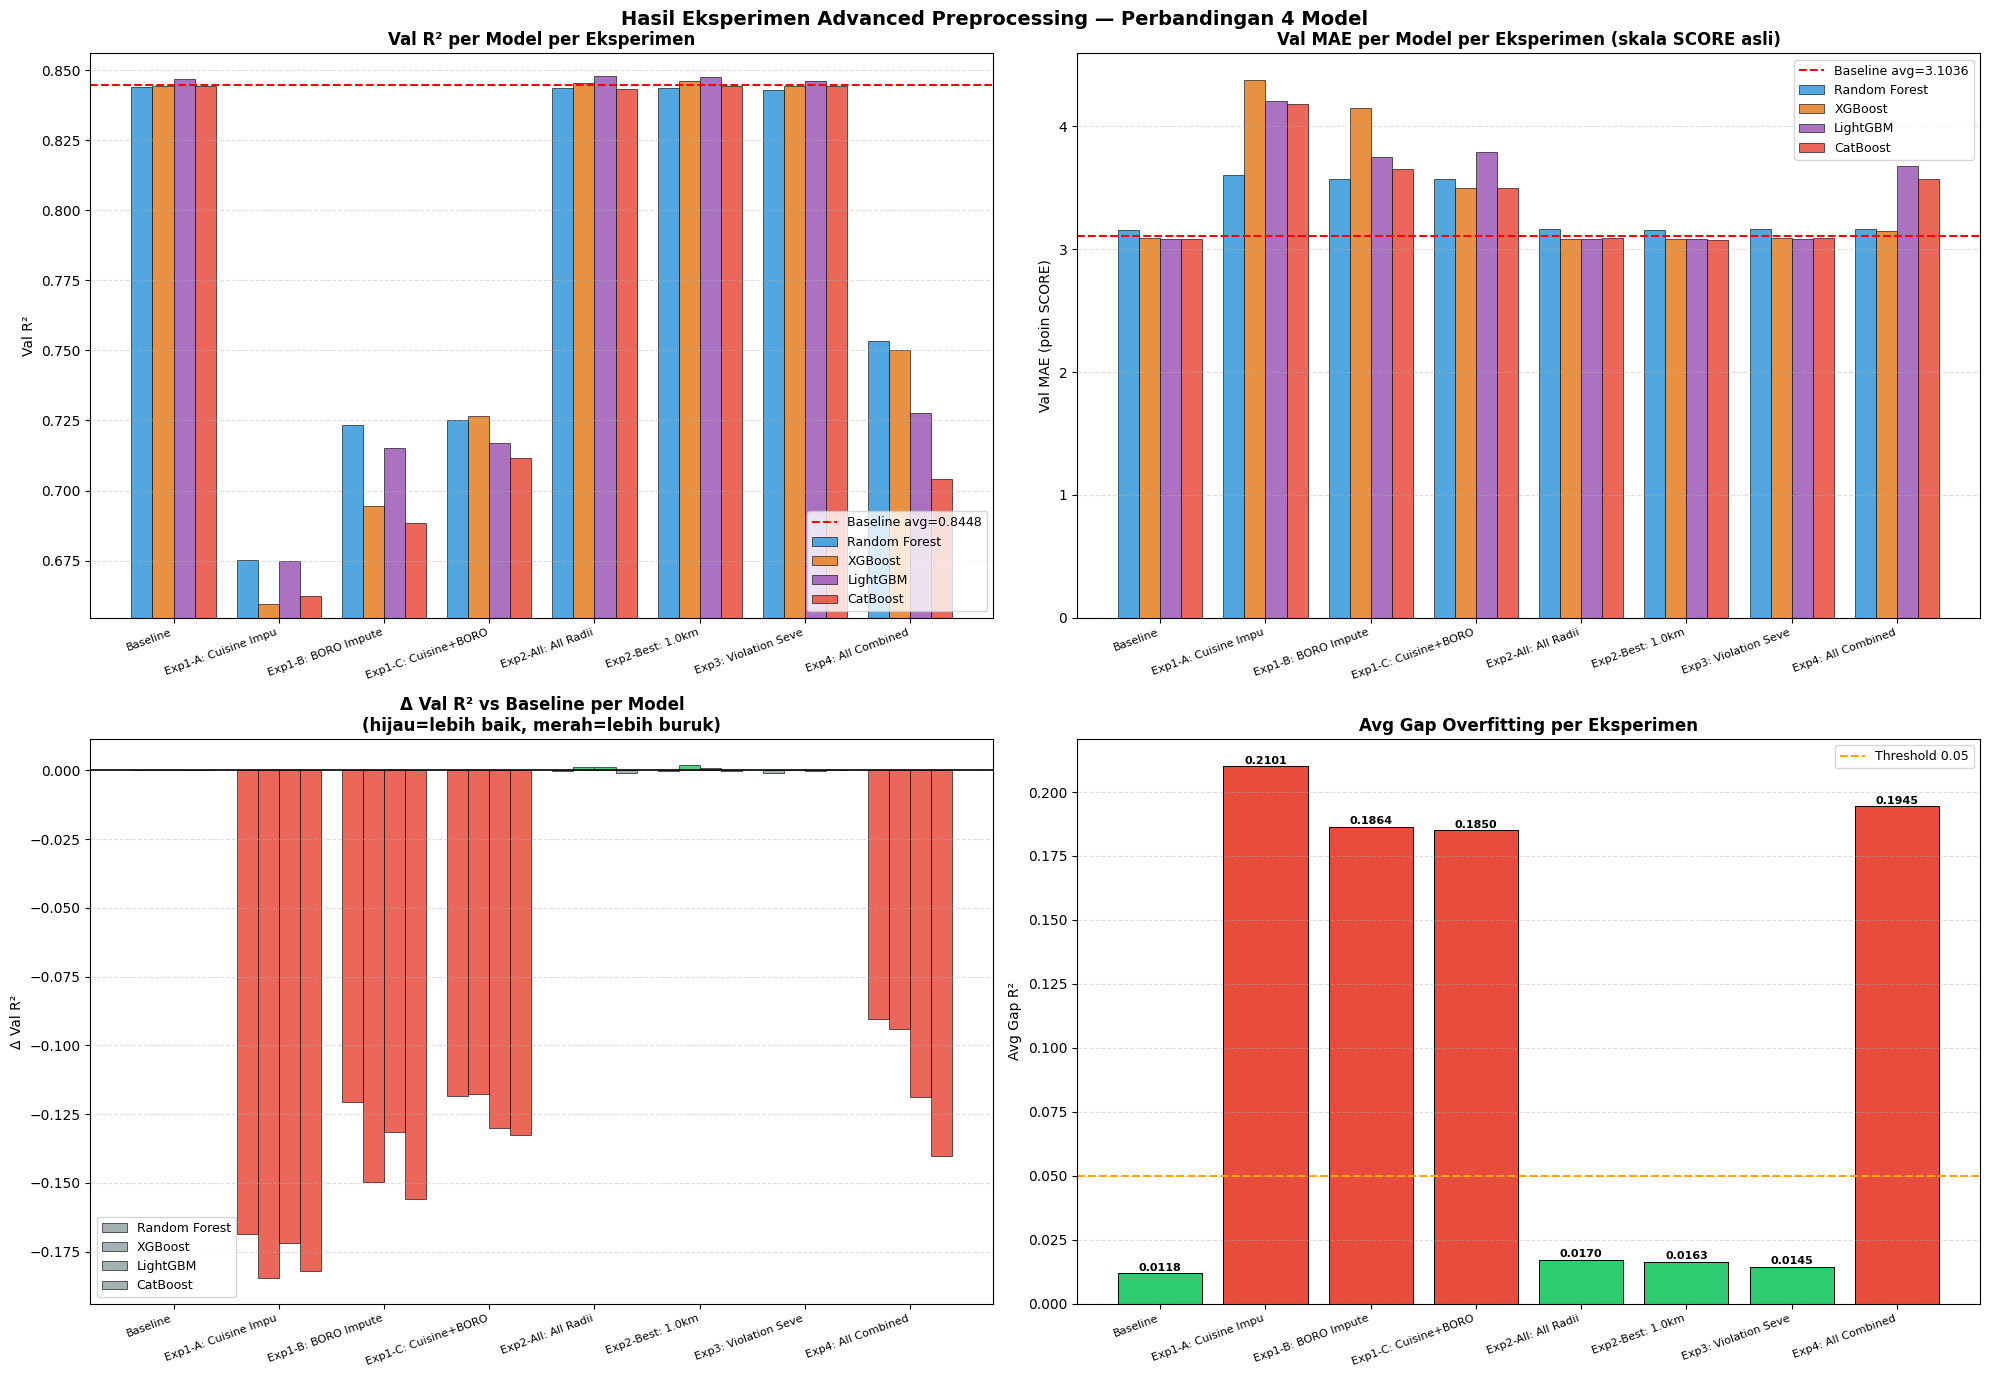

In [326]:
# ── Visualisasi komprehensif ──────────────────────────────────────────────────
experiments  = exp_summary["Experiment"].tolist()
models_list  = df_all["Model"].unique().tolist()
colors_model = {
    "Random Forest": "#3498db",
    "XGBoost":       "#e67e22",
    "LightGBM":      "#9b59b6",
    "CatBoost":      "#e74c3c",
}

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# ── Plot 1: Val R² ────────────────────────────────────────────────────────────
x     = np.arange(len(experiments))
width = 0.2

for j, model in enumerate(models_list):
    # Gunakan pivot agar tidak ada issue duplikat
    model_vals = (df_all[df_all["Model"] == model]
                  .drop_duplicates(subset=["Experiment"])   # ← fix duplikat
                  .set_index("Experiment")
                  .reindex(experiments)["Val R²"]
                  .values)
    offset = (j - 1.5) * width
    axes[0,0].bar(x + offset, model_vals, width,
                  label=model, color=colors_model[model],
                  edgecolor="black", linewidth=0.5, alpha=0.85)

axes[0,0].axhline(baseline_avg_r2, color="red", linestyle="--", linewidth=1.5,
                  label=f"Baseline avg={baseline_avg_r2:.4f}")
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels([e[:20] for e in experiments], rotation=20, ha="right", fontsize=8)
axes[0,0].set_title("Val R² per Model per Eksperimen", fontsize=12, fontweight="bold")
axes[0,0].set_ylabel("Val R²"); axes[0,0].legend(fontsize=9, loc="lower right")
axes[0,0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0,0].set_ylim(df_all["Val R²"].min()-0.005, df_all["Val R²"].max()+0.008)

# ── Plot 2: Val MAE ───────────────────────────────────────────────────────────
for j, model in enumerate(models_list):
    model_vals = (df_all[df_all["Model"] == model]
                  .drop_duplicates(subset=["Experiment"])
                  .set_index("Experiment")
                  .reindex(experiments)["Val MAE"]
                  .values)
    offset = (j - 1.5) * width
    axes[0,1].bar(x + offset, model_vals, width,
                  label=model, color=colors_model[model],
                  edgecolor="black", linewidth=0.5, alpha=0.85)

axes[0,1].axhline(baseline_avg_mae, color="red", linestyle="--", linewidth=1.5,
                  label=f"Baseline avg={baseline_avg_mae:.4f}")
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels([e[:20] for e in experiments], rotation=20, ha="right", fontsize=8)
axes[0,1].set_title("Val MAE per Model per Eksperimen (skala SCORE asli)",
                    fontsize=12, fontweight="bold")
axes[0,1].set_ylabel("Val MAE (poin SCORE)"); axes[0,1].legend(fontsize=9)
axes[0,1].grid(axis="y", linestyle="--", alpha=0.4)

# ── Plot 3: Δ Val R² ──────────────────────────────────────────────────────────
delta_data = delta_pivot.reset_index()
x3 = np.arange(len(delta_data))
for j, model in enumerate(models_list):
    if model not in delta_data.columns:
        continue
    vals = delta_data[model].values
    bar_colors = ["#2ecc71" if v > 0.001 else "#e74c3c" if v < -0.001 else "#95a5a6"
                  for v in vals]
    offset = (j - 1.5) * width
    axes[1,0].bar(x3 + offset, vals, width, color=bar_colors,
                  edgecolor="black", linewidth=0.5, alpha=0.85, label=model)

axes[1,0].axhline(0, color="black", linewidth=1.2)
axes[1,0].set_xticks(x3)
axes[1,0].set_xticklabels([e[:20] for e in delta_data["Experiment"].tolist()],
                           rotation=20, ha="right", fontsize=8)
axes[1,0].set_title("Δ Val R² vs Baseline per Model\n(hijau=lebih baik, merah=lebih buruk)",
                    fontsize=12, fontweight="bold")
axes[1,0].set_ylabel("Δ Val R²"); axes[1,0].legend(fontsize=9)
axes[1,0].grid(axis="y", linestyle="--", alpha=0.4)

# ── Plot 4: Gap overfitting ───────────────────────────────────────────────────
gap_summary = (df_all.groupby("Experiment")["Gap R²"]
               .mean()
               .reindex(experiments))
bar_colors4 = ["#2ecc71" if g <= 0.05 else "#e74c3c" for g in gap_summary]
bars4 = axes[1,1].bar(range(len(experiments)), gap_summary,
                       color=bar_colors4, edgecolor="black", linewidth=0.7)
axes[1,1].axhline(0.05, color="orange", linestyle="--", linewidth=1.5,
                  label="Threshold 0.05")
for bar, val in zip(bars4, gap_summary):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, val+0.001,
                   f"{val:.4f}", ha="center", fontsize=8, fontweight="bold")
axes[1,1].set_xticks(range(len(experiments)))
axes[1,1].set_xticklabels([e[:20] for e in experiments],
                           rotation=20, ha="right", fontsize=8)
axes[1,1].set_title("Avg Gap Overfitting per Eksperimen",
                    fontsize=12, fontweight="bold")
axes[1,1].set_ylabel("Avg Gap R²"); axes[1,1].legend(fontsize=9)
axes[1,1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Hasil Eksperimen Advanced Preprocessing — Perbandingan 4 Model",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [327]:
# ── Kesimpulan akhir ──────────────────────────────────────────────────────────
print("=" * 70)
print("  KESIMPULAN EKSPERIMEN")
print("=" * 70)

for _, row in exp_summary[exp_summary["Experiment"] != "Baseline"].iterrows():
    arrow = "↑" if row["Δ Avg R²"] > 0 else "↓" if row["Δ Avg R²"] < 0 else "→"
    print(f"\n{row['Experiment']}")
    print(f"  Avg Val R² : {row['Avg_Val_R2']:.4f}  ({arrow}{abs(row['Δ Avg R²']):.4f} vs baseline)")
    print(f"  Best Val R²: {row['Best_Val_R2']:.4f}")
    print(f"  Avg Val MAE: {row['Avg_Val_MAE']:.4f}  ({row['Status']})")

print(f"\n{'='*70}")
best_all = exp_summary.loc[exp_summary["Avg_Val_R2"].idxmax()]
print(f"🏆 Eksperimen terbaik: {best_all['Experiment']}")
print(f"   Avg Val R²  : {best_all['Avg_Val_R2']:.4f}")
print(f"   Avg Val MAE : {best_all['Avg_Val_MAE']:.4f}")
print(f"   Δ R² vs baseline: {best_all['Δ Avg R²']:+.4f}")


  KESIMPULAN EKSPERIMEN

Exp1-A: Cuisine Impute
  Avg Val R² : 0.6680  (↓0.1768 vs baseline)
  Best Val R²: 0.6752
  Avg Val MAE: 4.0919  (⚠️ Lebih buruk)

Exp1-B: BORO Impute
  Avg Val R² : 0.7052  (↓0.1396 vs baseline)
  Best Val R²: 0.7232
  Avg Val MAE: 3.7793  (⚠️ Lebih buruk)

Exp1-C: Cuisine+BORO+Flag
  Avg Val R² : 0.7201  (↓0.1247 vs baseline)
  Best Val R²: 0.7265
  Avg Val MAE: 3.5896  (⚠️ Lebih buruk)

Exp2-All: All Radii
  Avg Val R² : 0.8450  (↑0.0002 vs baseline)
  Best Val R²: 0.8480
  Avg Val MAE: 3.1057  (→ Sama)

Exp2-Best: 1.0km
  Avg Val R² : 0.8454  (↑0.0006 vs baseline)
  Best Val R²: 0.8475
  Avg Val MAE: 3.0978  (→ Sama)

Exp3: Violation Severity
  Avg Val R² : 0.8445  (↓0.0003 vs baseline)
  Best Val R²: 0.8463
  Avg Val MAE: 3.1062  (→ Sama)

Exp4: All Combined
  Avg Val R² : 0.7339  (↓0.1109 vs baseline)
  Best Val R²: 0.7535
  Avg Val MAE: 3.3880  (⚠️ Lebih buruk)

🏆 Eksperimen terbaik: Exp2-Best: 1.0km
   Avg Val R²  : 0.8454
   Avg Val MAE : 3.0978
   Δ R